In [1]:
import os
import numpy as np
import torch
import pickle

from sensorium.utility import get_data, set_random_seed
from sensorium.utility.scores import get_correlations

from utils import load_model_from_config, get_knn_curve, get_ari_curve, whiten, get_cka, get_rsa, get_metrics
import matplotlib.pyplot as plt

random_seed = 42
set_random_seed(random_seed, deterministic=False)

device = 'cuda:7'
torch.cuda.set_device(device)

basepath = "/srv/user/polina/sensorium/sensorium/notebooks/data/"
# as filenames, we'll select all 7 datasets

filenames = [] 
for file in [
    'static23343-5-17-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static23964-4-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
    'static23656-14-22-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static21067-10-18-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static22846-10-16-GrayImageNet-94c6ff995dac583098847cfecd43e7b6', 
    'static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6',
]:
    filenames.append(os.path.join(basepath, file))

dataset_fn = "sensorium.datasets.static_loaders"

dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": True,
    "include_eye_position": True,
    "exclude_eye_position_paths": [
        '/srv/user/polina/sensorium/sensorium/notebooks/data/static26872-17-20-GrayImageNet-94c6ff995dac583098847cfecd43e7b6'
    ],
    "batch_size": 128,
    "scale": 0.25,
}
dataloaders = get_data(dataset_fn, dataset_config)
data_keys = list(dataloaders['train'].keys())

# whitening

## cov matrix

In [2]:
path = '../training/runs/baseline/baseline_seed9'
model = load_model_from_config(path, dataloaders, device)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [9]:
# load batches and save feature vecs
num_batches = 50
n_subsample = 100

features = {}
for mode in ['train', 'validation']:
    mode_features = []
    for key in data_keys:
        batch_features = []
        for i, batch in enumerate(dataloaders[mode][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature.detach().cpu()
            if mode == 'train':
                subsample = torch.randperm(feature.shape[1])[:n_subsample]
                feature = feature[:, subsample, :]
            batch_features.append(feature)
        mode_features.append(torch.cat(batch_features))

    flattened = torch.cat([f.flatten(0, 1) for f in mode_features])
    features[mode] = flattened

In [10]:
# helper for mu, cov and corr computation
def get_stats(X):
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    std = cov.diag().sqrt()
    cor = cov / torch.outer(std, std)
    return mu, cov, cor

In [11]:
val_mu, val_cov, val_cor = get_stats(features['validation'])

In [12]:
# whiten
train_mu, train_cov, train_cor = get_stats(features['train'])

eye = torch.eye(train_cov.shape[0])
L = torch.linalg.cholesky(train_cov + 1e-5 * eye)
W = torch.linalg.inv(L).T

X = features['validation']
Xw = (X - train_mu) @ W

white_mu, white_cov, white_cor = get_stats(Xw)

In [37]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


def plot_corr_matrices(corr1, corr2,
                       cmap="RdBu_r",
                       bins=30):

    # ------------------------------------------------------------
    # 1. Get the ordering from seaborn's clustering
    # ------------------------------------------------------------
    def get_cluster_order(corr):
        # Temporary clustermap only to obtain the ordering
        g = sns.clustermap(
            corr,
            row_cluster=True,
            col_cluster=True,
            cmap=cmap,
            xticklabels=False,
            yticklabels=False,
        )

        order = g.dendrogram_row.reordered_ind
        plt.close(g.fig)

        return order

    order = get_cluster_order(corr1)
    corr1_ordered = np.asarray(corr1)[np.ix_(order, order)]
    corr2_ordered = np.asarray(corr2)[np.ix_(order, order)]

    # ------------------------------------------------------------
    # 2. Fixed color scale centered at zero
    # ------------------------------------------------------------
    norm = TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

    # ------------------------------------------------------------
    # 3. Figure
    # ------------------------------------------------------------
    fig, axes = plt.subplots(
        1, 2,
        figsize=(7.2, 3.6),
        constrained_layout=True
    )

    matrices = [corr1_ordered, corr2_ordered]

    # ------------------------------------------------------------
    # 4. Histogram of off-diagonal values
    #    Use the same symmetric x-limits and ticks for both
    # ------------------------------------------------------------

    # Get off-diagonal values from both matrices
    off_diag_values = []

    for matrix in matrices:
        off_diag = matrix[~np.eye(matrix.shape[0], dtype=bool)]
        off_diag_values.append(off_diag)

    # Maximum absolute off-diagonal value across BOTH matrices
    max_abs = max(
        np.max(np.abs(values))
        for values in off_diag_values
    )

    # Optional: round upward to a clean value
    xlim = np.ceil(max_abs * 10) / 10

    # Common ticks, symmetric around zero
    ticks = np.linspace(-xlim, xlim, 3)

    ax_letters = [['A', 'C'], ['B', 'D']]

    for ax, matrix, off_diag, letters in zip(
        axes,
        matrices,
        off_diag_values,
        ax_letters,
    ):
        # Heatmap
        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            norm=norm,
            square=True,
            cbar=False,
            xticklabels=False,
            yticklabels=False,
        )

        ax.text(
            0.17, 0.9, letters[0],
            transform=ax.transAxes,
            fontsize=20,
            fontweight='bold',
            va='bottom',
            ha='right',
        )

        # Histogram inset
        hist_ax = inset_axes(
            ax,
            width="42%",
            height="42%",
            loc="upper right",
            # borderpad=1.0,
        )

        hist_ax.hist(
            off_diag,
            bins=bins,
            range=(-xlim, xlim),
            color='black',
        )

        # Same limits and ticks for both histograms
        hist_ax.set_xlim(-xlim, xlim)
        hist_ax.set_xticks([-0.5, 0, 0.5])

        hist_ax.tick_params(
            axis="both",
            # labelsize=7,
            # length=2,
        )

        hist_ax.set_facecolor("white")
        hist_ax.spines['top'].set_visible(False)
        hist_ax.spines['right'].set_visible(False)

        hist_ax.text(
            0.2, 0.75, letters[1],
            transform=hist_ax.transAxes,
            fontsize=20,
            fontweight='bold',
            va='bottom',
            ha='right',
        )

    # One shared colorbar
    sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    fig.colorbar(
        sm,
        ax=axes,
        shrink=0.8,
        label="Correlation",
    )

    return fig, axes

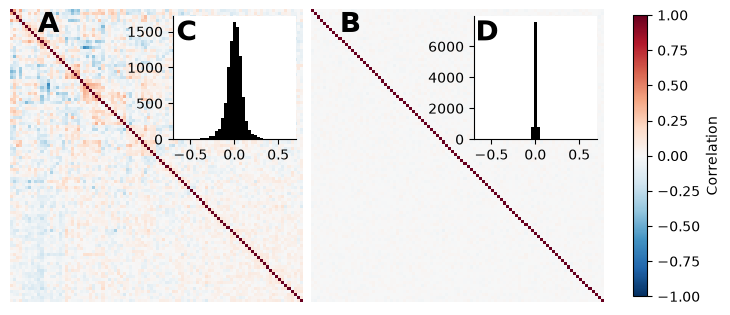

In [38]:
fig, axes = plot_corr_matrices(
    val_cor,
    white_cor,
    bins=41,
)
plt.savefig(
    'plots/whitening_results.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## non-ortho basis example

In [23]:
n = 400
X = torch.randn(n, 2)
B = torch.tensor(
    [[0, 1], 
     [2, 2]], 
    dtype=torch.float32
)
Q = torch.tensor(
    [[0, -2], 
     [-2, 0]], 
    dtype=torch.float32
)
XB = X @ torch.linalg.inv(B).T
XQ = X @ torch.linalg.inv(Q).T

k = 100
distsB = (XB - XB[0]).pow(2).sum(-1).sqrt()
distsQ = (XQ - XQ[0]).pow(2).sum(-1).sqrt()
nnB = distsB.argsort()[1:(k+1)]
nnQ = distsQ.argsort()[1:(k+1)]

shared = nnB[torch.isin(nnB, nnQ)]
onlyB = nnB[~torch.isin(nnB, shared)]
onlyQ = nnQ[~torch.isin(nnQ, shared)]

combined = torch.cat([nnB, nnQ])
rem = torch.arange(1, n)[~torch.isin(torch.arange(1, n), combined)]

/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/user/nathanpaul.soeding/sensorium/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:208: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


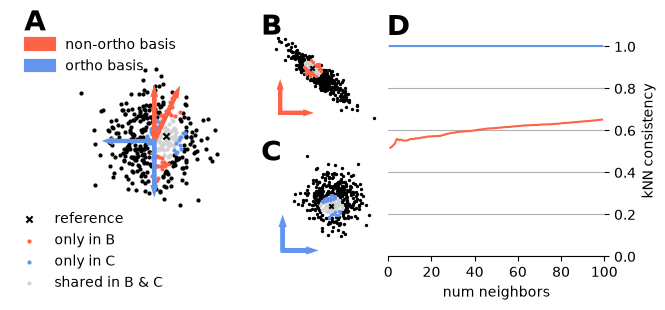

In [88]:
from matplotlib.gridspec import GridSpecFromSubplotSpec

fig = plt.figure(figsize=(7.2, 3))

# Main layout: left | center | right
gs = fig.add_gridspec(1, 3, width_ratios=[1, 0.5, 1], wspace=0.05)

axs_left = fig.add_subplot(gs[0])
axs_right = fig.add_subplot(gs[2])

# Split the middle column vertically
gs_middle = GridSpecFromSubplotSpec(
    2, 1,
    subplot_spec=gs[1],
    wspace=0.0,
)

axs_center_top = fig.add_subplot(gs_middle[0])
axs_center_bottom = fig.add_subplot(gs_middle[1])

colors = {
    'data': 'black',
    'non-ortho': 'tomato',
    'ortho': 'cornflowerblue',
    'shared': 'lightgray',
}

ps = 4
data = axs_left.scatter(X[rem, 0], X[rem, 1], color=colors['data'], s=ps)
s = axs_left.scatter(X[shared, 0], X[shared, 1], color=colors['shared'], s=ps, label='shared in B & C')
oB = axs_left.scatter(X[onlyB, 0], X[onlyB, 1], color=colors['non-ortho'], s=ps, label='only in B')
oQ = axs_left.scatter(X[onlyQ, 0], X[onlyQ, 1], color=colors['ortho'], s=ps, label='only in C')
ref = axs_left.scatter(X[0, 0], X[0, 1], color=colors['data'], s=20, marker='x', label='reference')
nonortho = axs_left.arrow(0, 0, B[0, 0], B[1, 0], color=colors['non-ortho'], linewidth=3, head_width=0.1, label='non-ortho basis')
axs_left.arrow(0, 0, B[0, 1], B[1, 1], color=colors['non-ortho'], linewidth=3, head_width=0.1)
ortho = axs_left.arrow(0, 0, Q[0, 0], Q[1, 0], color=colors['ortho'], linewidth=3, head_width=0.1, label='ortho basis')
axs_left.arrow(0, 0, Q[0, 1], Q[1, 1], color=colors['ortho'], linewidth=3, head_width=0.1)
axs_left.set_xticks([])
axs_left.set_yticks([])
# axs_left.axis('equal')
axs_left.set_ylim(-5, 5)
axs_left.set_xlim(-5, 5)
for spine in axs_left.spines.values():
    spine.set_visible(False)
legend1 = axs_left.legend(handles=[nonortho, ortho], frameon=False, loc='upper left', bbox_to_anchor=(-0.15, 1.0))
axs_left.add_artist(legend1)
axs_left.legend(handles=[ref, oB, oQ, s], frameon=False, loc='lower left', bbox_to_anchor=(-0.2, -0.2))
axs_left.text(
    0.0, 0.95, 'A',
    transform=axs_left.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

ps = 2
axs_center_top.scatter(XB[rem, 0], XB[rem, 1], color=colors['data'], s=ps)
axs_center_top.scatter(XB[onlyQ, 0], XB[onlyQ, 1], color=colors['data'], s=ps)
axs_center_top.scatter(XB[shared, 0], XB[shared, 1], color=colors['shared'], s=ps)
axs_center_top.scatter(XB[onlyB, 0], XB[onlyB, 1], color=colors['non-ortho'], s=ps)
axs_center_top.scatter(XB[0, 0], XB[0, 1], color=colors['data'], s=10, marker='x')
axs_center_top.arrow(-3, -3, 0, 2, color=colors['non-ortho'], linewidth=3, head_width=0.1)
axs_center_top.arrow(-3, -3, 2, 0, color=colors['non-ortho'], linewidth=3, head_width=0.1)
axs_center_top.axis('equal')
axs_center_top.set_xticks([])
axs_center_top.set_yticks([])
for spine in axs_center_top.spines.values():
    spine.set_visible(False)
axs_center_top.text(
    0.1, 0.85, 'B',
    transform=axs_center_top.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

axs_center_bottom.scatter(XQ[rem, 0], XQ[rem, 1], color=colors['data'], s=ps)
axs_center_bottom.scatter(XQ[onlyB, 0], XQ[onlyB, 1], color=colors['data'], s=ps)
axs_center_bottom.scatter(XQ[shared, 0], XQ[shared, 1], color=colors['shared'], s=ps)
axs_center_bottom.scatter(XQ[onlyQ, 0], XQ[onlyQ, 1], color=colors['ortho'], s=ps)
axs_center_bottom.scatter(XQ[0, 0], XQ[0, 1], color=colors['data'], s=10, marker='x')
axs_center_bottom.arrow(-2, -2, 0, 1, color=colors['ortho'], linewidth=3, head_width=0.1)
axs_center_bottom.arrow(-2, -2, 1, 0, color=colors['ortho'], linewidth=3, head_width=0.1)
axs_center_bottom.axis('equal')
axs_center_bottom.set_xticks([])
axs_center_bottom.set_yticks([])
for spine in axs_center_bottom.spines.values():
    spine.set_visible(False)
axs_center_bottom.text(
    0.1, 0.85, 'C',
    transform=axs_center_bottom.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

knn_curve, k_range = get_knn_curve([X, XB], k_range=np.unique(np.arange(1, 100)))
axs_right.plot(k_range, knn_curve[0], color=colors['non-ortho'])
knn_curve, k_range = get_knn_curve([X, XQ], k_range=np.unique(np.arange(1, 100)))
axs_right.plot(k_range, knn_curve[0], color=colors['ortho'])
axs_right.set_xlabel('num neighbors')
axs_right.set_ylabel('kNN consistency')
axs_right.yaxis.set_label_position('right')
axs_right.yaxis.tick_right()
axs_right.set_xlim(0, 100)
axs_right.set_ylim(0, 1.1)
axs_right.spines['top'].set_visible(False)
axs_right.spines['left'].set_visible(False)
axs_right.spines['right'].set_visible(False)
# axs_right.spines['bottom'].set_visible(False)
axs_right.grid(axis='y')
axs_right.text(
    0.1, 0.93, 'D',
    transform=axs_right.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.savefig(
    'plots/whitening_example.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# rfs

## results plot

In [2]:
h, w = 28, 56
paths = [
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed9',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed87',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed333',
]

base_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    base_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]

new_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    new_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [4]:
base_scores = []
for model in base_models:
    model_scores = get_correlations(model, dataloaders['test'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    base_scores.append(model_scores)

new_scores = []
for model in new_models:
    model_scores = get_correlations(model, dataloaders['test'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    new_scores.append(model_scores)

performance = {
    "Gaussian": base_scores,
    "ReFL": new_scores,
}

In [17]:
base_grids = []
for model in base_models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        # grid = grid - grid.mean(0, keepdim=True)

        grids.append(grid)

    base_grids.append(grids)

In [18]:
new_grids = []
for model in new_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        # grid = grid - grid.mean(0, keepdim=True)
        grids.append(grid)

    new_grids.append(grids)

In [19]:
model_seeds = [9, 87, 333]
model_types = {
    "Gaussian": base_grids,
    "ReFL": new_grids,
}

num_models = len(model_seeds)

In [20]:
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)

    metric[type_name] = model_avgs

In [21]:
def plot_rf_grids(mice=[0, 1, 2], figsize=(10, 6), metric_name='RF\n Distance', height_ratios=[1.5, 1.5, 0.5, 3, 0.1, 1.5]):
    fig = plt.figure(figsize=figsize)

    mice = np.array(mice)

    gs = fig.add_gridspec(
        6, len(mice),
        height_ratios=height_ratios,
        hspace=0.05,
        wspace=0.0,
    )

    # Two metric axes, each spanning all 4 columns
    ax_performance = fig.add_subplot(gs[0, :])
    ax_metric = fig.add_subplot(gs[1, :])

    # Bottom: 2 x 4 grid of point plots
    axs = np.empty((2, len(mice)), dtype=object)

    for row in range(2):
        for col in range(len(mice)):
            axs[row, col] = fig.add_subplot(
                gs[3 + row * 2, col],
                # sharex=axs[0, col] if row > 0 else None,
                sharey=axs[row, 0] if col > 0 else None,
                sharex=axs[0, 0],# if row > 0 else None,
                # sharey=axs[0, 0],# if col > 0 else None,
            )

    model_colors = {
        "Gaussian": ['navy', 'royalblue', 'lightskyblue'],
        "ReFL": ['maroon', 'firebrick', 'salmon'],
    }

    for ax, metric_data in [
        (ax_performance, performance),
        (ax_metric, metric),
    ]:

        offsets = [-0.1, 0.1]
        for model_idx, (type_name, values) in enumerate(metric_data.items()):

            # values: [seed, mouse]
            values = np.asarray(values)

            means = values.mean(axis=0)
            stds = values.std(axis=0, ddof=1)

            x = np.arange(len(mice)) + offsets[model_idx]
            
            ax.errorbar(
                x,
                means[mice],
                yerr=stds[mice],
                fmt='o',
                # capsize=4,
                # capthick=2,
                linewidth=2,
                label=type_name,
                color=model_colors[type_name][1],
            )

        ax.set_xticks([])
        margin = 0.46
        ax.set_xlim(0 - margin, len(mice) - 1 + margin)


        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y')

    ax_performance.set_ylabel('Performance')
    ax_metric.set_ylabel(metric_name, labelpad=13)

    for row_idx, (type_name, grids) in enumerate(model_types.items()):
        for i, mouse_idx in enumerate(mice):
            ax = axs[row_idx, i]
            
            for model_idx in range(num_models):
                grid = grids[model_idx][mouse_idx]

                ax.scatter(
                    grid[:, 0],
                    grid[:, 1],
                    alpha=1.0,
                    s=0.05,
                    color=model_colors[type_name][model_idx],
                    label=f"seed {model_seeds[model_idx]}",
                )

            ax.set_aspect('equal')#, adjustable='datalim') #, adjustable='box')#
    
            for spine in ax.spines.values():
                spine.set_visible(False)

    axs[0, 0].set_ylabel("H'", y=0.2)#, loc='bottom')
    axs[1, 1].set_xlabel("W'")

    for col in range(len(mice)):
        axs[0, col].set_xticks([20, 25, 30])
        axs[0, col].tick_params(axis='x', labelbottom=False, bottom=False)
    for row in range(2):
        for col in range(1, len(mice)):
            axs[row, col].tick_params(axis='y', labelleft=False, left=False)

    ax_metric.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.03, 1.7))

    handles, labels = axs[0, 0].get_legend_handles_labels()
    axs[0, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 1.2),
        loc='upper right',
        markerscale=20,
        frameon=False,
        ncol=3,
    )
    
    handles, labels = axs[1, 0].get_legend_handles_labels()
    axs[1, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 1.4),
        loc='upper right',
        markerscale=20,
        frameon=False,
        ncol=3,
    )

    for i in range(len(mice)):
        ax = axs[0, i]
        bbox = ax.get_position()

        fig.text(
            bbox.x0 + bbox.width / 2,
            0.92,
            f"Mouse {mice[i] + 1}",
            ha="center",
            va="top",
        )

    ax_performance.text(
        0.0, 0.85, 'A',
        transform=ax_performance.transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

    ax_metric.text(
        0.0, 0.65, 'B',
        transform=ax_metric.transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

    axs[0, 0].text(
        0.15, 0.8, 'C',
        transform=axs[0, 0].transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

    axs[1, 0].text(
        0.15, 0.8, 'D',
        transform=axs[1, 0].transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

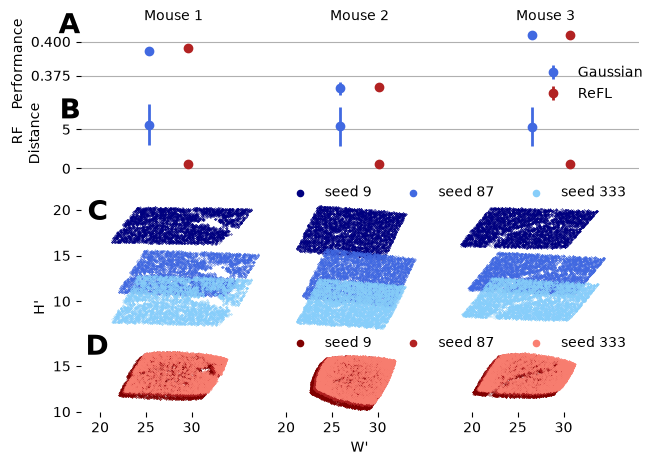

In [22]:
plot_rf_grids(mice=list(range(3)), figsize=(7.2, 5), height_ratios=[1.5, 1.5, 0.5, 3, 0.1, 1.5])

plt.savefig(
    'plots/results_readout.png',
    dpi=400,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## 7 mice version

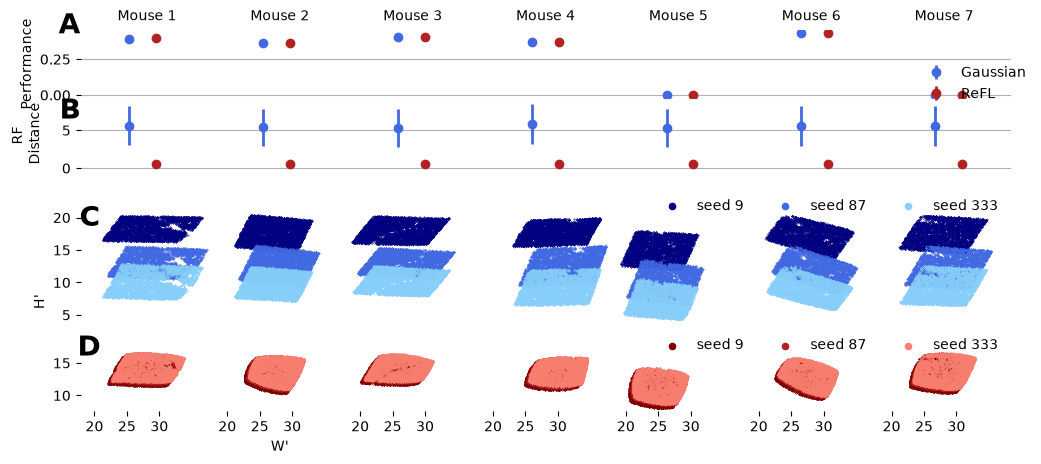

In [24]:
plot_rf_grids(mice=list(range(7)), figsize=(12, 5), height_ratios=[1.5, 1.5, 0.5, 3, 0.1, 1.5])

plt.savefig(
    'plots/apx_readout_7mice.png',
    dpi=400,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## mean centered version

In [25]:
base_grids = []
for model in base_models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grid = grid - grid.mean(0, keepdim=True)

        grids.append(grid)

    base_grids.append(grids)

new_grids = []
for model in new_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grid = grid - grid.mean(0, keepdim=True)
        grids.append(grid)

    new_grids.append(grids)

model_seeds = [9, 87, 333]
model_types = {
    "Gaussian": base_grids,
    "ReFL": new_grids,
}

num_models = len(model_seeds)
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)

    metric[type_name] = model_avgs

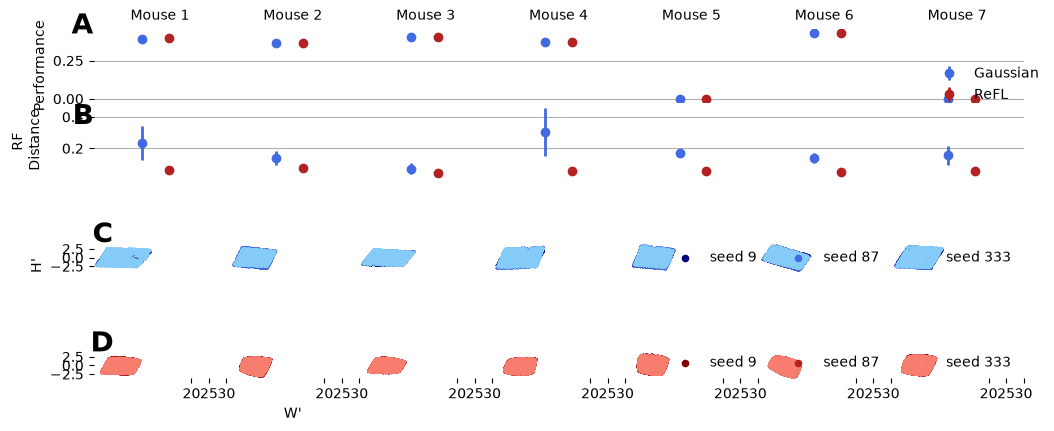

In [26]:
plot_rf_grids(mice=list(range(7)), figsize=(12, 5), height_ratios=[1.5, 1.5, 0.5, 2, 0.1, 2])

plt.savefig(
    'plots/apx_readout_7mice_centered.png',
    dpi=400,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## shifter version

In [83]:
base_shifts = []
for model in base_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = (shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = (shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    base_shifts.append(shifts)

In [84]:
new_shifts = []
for model in new_models:
    shifts = []
    for key in data_keys:
        shift_batches = []
        for batch in dataloaders['validation'][key]:
            if len(batch) == 4:
                _, _, _, pupil = batch

                shift = model.shifter[key](pupil).detach().cpu()
                shift[:, 0] = -(shift[:, 0]) / 2 * w  # rescale to from [-1, 1] to [0, w] 
                shift[:, 1] = -(shift[:, 1]) / 2 * h  # rescale to from [-1, 1] to [0, h]
                shift_batches.append(shift)
        if len(shift_batches) > 0:
            shifts.append(torch.cat(shift_batches))
        else:
            shifts.append(torch.empty(0, 2))
    new_shifts.append(shifts)

In [85]:
model_seeds = [9, 87, 333]
model_types = {
    "Gaussian": base_shifts,
    "ReFL": new_shifts,
}

num_models = len(model_seeds)

In [86]:
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)
    metric[type_name] = model_avgs

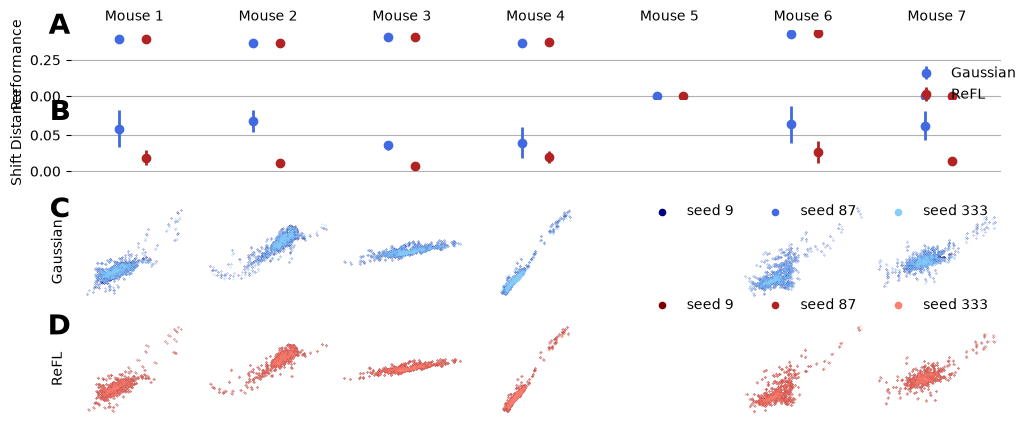

In [87]:
plot_rf_grids(mice=[0, 1, 2, 3, 4, 5, 6], figsize=(12, 5), metric_name='Shift Distance', height_ratios=[1.5, 1.5, 0.6, 2, 0.4, 2])

plt.savefig(
    'plots/apx_shifter.png',
    dpi=400,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## frozen core version

In [88]:
paths = [
    '../training/runs/frozen_core/baseline/seed7/frozen_core_baseline_seed7',
    '../training/runs/frozen_core/baseline/seed50/frozen_core_baseline_seed50',
    '../training/runs/frozen_core/baseline/seed444/frozen_core_baseline_seed444',
]

frozen_base_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device, strict=False)
    frozen_base_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [89]:
paths = [
    '../training/runs/frozen_core/new/seed7/frozen_core_new_seed7',
    '../training/runs/frozen_core/new/seed50/frozen_core_new_seed50',
    '../training/runs/frozen_core/new/seed444/frozen_core_new_seed444',
]

frozen_new_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device, strict=False)
    frozen_new_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [90]:
base_scores = []
for model in frozen_base_models:
    model_scores = get_correlations(model, dataloaders['test'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    base_scores.append(model_scores)

new_scores = []
for model in frozen_new_models:
    model_scores = get_correlations(model, dataloaders['test'], device=device, as_dict=True)
    model_scores = [v.mean() for v in model_scores.values()]
    new_scores.append(model_scores)

performance = {
    "Gaussian": base_scores,
    "ReFL": new_scores,
}

In [91]:
h, w = 28, 56
base_grids = []
for model in frozen_base_models:
    grids = []
    for key in data_keys:
        grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
        grid[:, 0] = (grid[:, 0] + 1) / 2 * w
        grid[:, 1] = (grid[:, 1] + 1) / 2 * h

        grids.append(grid)

    base_grids.append(grids)

In [92]:
new_grids = []
for model in frozen_new_models:
    grids = []
    for key in data_keys:
        spatial = model.readout[key].spatial.detach().cpu()
        n, h, w = spatial.shape
        y = spatial.sum(dim=2)  # n, h
        x = spatial.sum(dim=1)  # n, w

        y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
        x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)
        
        grid = torch.stack([x_avg, y_avg], dim=1)
        grids.append(grid)

    new_grids.append(grids)

In [93]:
model_seeds = [7, 50, 444]
model_types = {
    "Gaussian": base_grids,
    "ReFL": new_grids,
}

num_models = len(model_seeds)

In [94]:
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)
    metric[type_name] = model_avgs

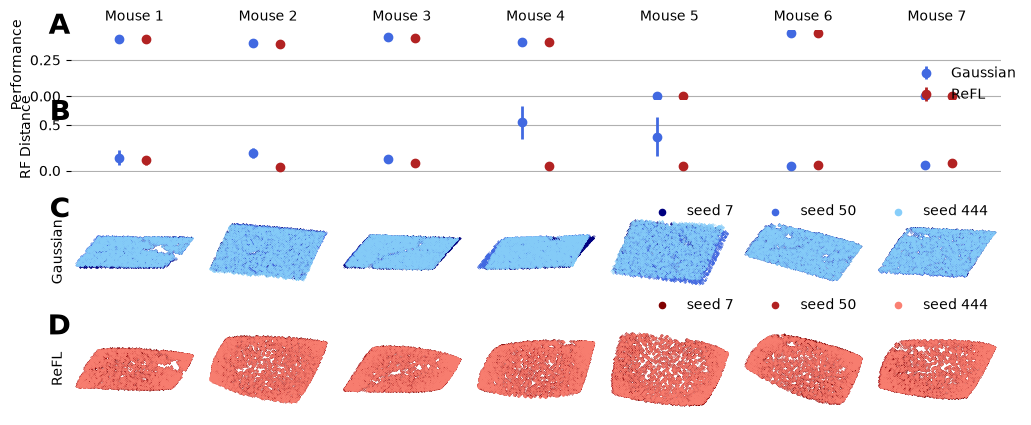

In [95]:
plot_rf_grids(mice=[0, 1, 2, 3, 4, 5, 6], figsize=(12, 5), height_ratios=[1.5, 1.5, 0.6, 2, 0.4, 2])

plt.savefig(
    'plots/apx_readout_frozen_core.png',
    dpi=400,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# knn

## results plot

In [2]:
paths = [
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed9',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed87',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed333',
]

base_models = [
    load_model_from_config(path, dataloaders, device)
    for path in paths
]

paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]

new_models = [
    load_model_from_config(path, dataloaders, device)
    for path in paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
num_batches = 50

In [4]:
base_readouts = [
    torch.cat([model.readout[k].features.squeeze().T.detach().cpu() for k in data_keys])
    for model in base_models
]

cache_file = 'data/base_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        base_white_readouts = pickle.load(f)
else:
    base_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=True, n_subsample=100) 
        for model in base_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(base_white_readouts, f)

In [5]:
new_readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in new_models
]

cache_file = 'data/new_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        new_white_readouts = pickle.load(f)
else:
    new_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100) 
        for model in new_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(new_white_readouts, f)

In [6]:
normed_base_readouts = [r / r.norm(dim=1, keepdim=True) for r in base_readouts]
normed_new_readouts = [r / r.norm(dim=1, keepdim=True) for r in new_readouts]
normed_base_white_readouts = [r / r.norm(dim=1, keepdim=True) for r in base_white_readouts]
normed_new_white_readouts = [r / r.norm(dim=1, keepdim=True) for r in new_white_readouts]

In [7]:
k_range = np.unique(np.geomspace(10, 1000, num=20, dtype=int))
n_range = np.unique(np.geomspace(5, 100, num=20, dtype=int))

In [8]:
cache_file = 'data/metrics.pkl'

if os.path.exists(cache_file):
    with open(cache_file, "rb") as f:
        cache = pickle.load(f)
    base_metrics = cache['base_metrics']
    base_white_metrics = cache['base_white_metrics']
    new_metrics = cache['new_metrics']
    new_white_metrics = cache['new_white_metrics']
else:
    seeds = [0, 42, 123, 333, 555]
    base_metrics = get_metrics(normed_base_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('base')
    base_white_metrics = get_metrics(normed_base_white_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('base white')
    new_metrics = get_metrics(normed_new_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('new')
    new_white_metrics = get_metrics(normed_new_white_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('new white')

    with open(cache_file, 'wb') as f:
        pickle.dump({
            'base_metrics': base_metrics,
            'base_white_metrics': base_white_metrics,
            'new_metrics': new_metrics,
            'new_white_metrics': new_white_metrics,
        }, f)

In [9]:
def plot_knn_ari(metrics, colors, rotation=20, offset=15, ha='center', fontsize=None):
    fig, axs = plt.subplots(1, 4, figsize=(12, 2.8))
    plt.subplots_adjust(wspace=0.3)

    def plot_curves(ax, x, curves):
        for label, curve in curves.items():
            curve, _ = curve
            m, s = np.array(curve[0]), np.array(curve[1])
            ax.plot(x, m, label=label, color=colors[label], linestyle='--', marker='o', markersize=4)
            ax.fill_between(x, m - s, m + s, alpha=0.2, color=colors[label])

    def plot_bar(ax, values, ylabel):
        labels = list(values.keys())
        means = [values[l][0] for l in labels]
        stds = [values[l][1] for l in labels]
        bar_colors = [colors[l] for l in labels]

        ax.bar(labels, means, yerr=stds, color=bar_colors, capsize=4,
               edgecolor=None, linewidth=2, alpha=1)
        ax.set_ylabel(ylabel, labelpad=0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y')
        ax.set_xticks(labels)
        ax.set_xticklabels(labels, rotation=rotation, rotation_mode='anchor', ha=ha)
        ax.tick_params(axis='x', pad=offset)

    knn_curves = metrics['kNN consistency']
    ax = axs[0]
    plot_curves(ax, k_range, knn_curves)
    ax.set_xlabel('num neighbors')
    ax.set_ylabel('kNN consistency', labelpad=0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y')
    ax.set_xscale('log')
    pos_x, pos_y = 0.13, 0.9
    ax.text( pos_x, pos_y, 'A', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

    ari_curves = metrics['ARI']
    ax = axs[1]
    plot_curves(ax, n_range, ari_curves)
    ax.set_xticks([5, 25, 50, 75, 100])
    ax.set_xlabel('num clusters')
    ax.set_ylabel('ARI', labelpad=0)
    ax.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.2, 1.0), fontsize=fontsize)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y')
    ax.text(pos_x, pos_y, 'B', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

    cka = metrics['CKA']
    rsa = metrics['RSA']

    plot_bar(axs[2], cka, 'CKA')
    plot_bar(axs[3], rsa, 'RSA')
    axs[2].text(pos_x, pos_y, 'C', transform=axs[2].transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')
    axs[3].text(pos_x, pos_y, 'D', transform=axs[3].transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

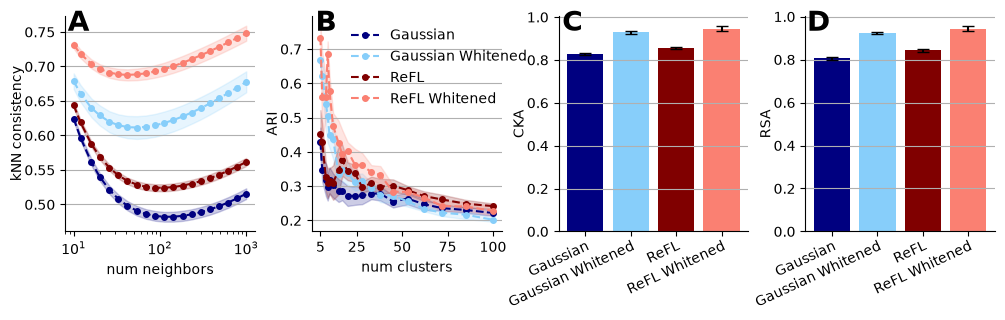

In [10]:
keys = ['Gaussian' , 'Gaussian Whitened', 'ReFL', 'ReFL Whitened']
metric_list = [base_metrics, base_white_metrics, new_metrics, new_white_metrics]
color_list = ['navy', 'lightskyblue', 'maroon', 'salmon']

metrics = {
    metric: {k: m[metric] for k, m in zip(keys, metric_list)}
    for metric in base_metrics.keys()
}
colors = dict(zip(keys, color_list))

plot_knn_ari(metrics, colors, ha='right', offset=2, rotation=25)

plt.savefig(
    'plots/results_metrics.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## with/without normalizing

In [11]:
cache_file = 'data/no_norm_metrics.pkl'

if os.path.exists(cache_file):
    with open(cache_file, "rb") as f:
        cache = pickle.load(f)
    non_base_metrics = cache['base_metrics']
    non_base_white_metrics = cache['base_white_metrics']
    non_new_metrics = cache['new_metrics']
    non_new_white_metrics = cache['new_white_metrics']
else:
    seeds = [0, 42, 123, 333, 555]
    non_base_metrics = get_metrics(base_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('base')
    non_base_white_metrics = get_metrics(base_white_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('base white')
    non_new_metrics = get_metrics(new_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('new')
    non_new_white_metrics = get_metrics(new_white_readouts, k_range, n_range, chance_adjust=True, seeds=seeds)
    print('new white')

    with open(cache_file, 'wb') as f:
        pickle.dump({
            'base_metrics': non_base_metrics,
            'base_white_metrics': non_base_white_metrics,
            'new_metrics': non_new_metrics,
            'new_white_metrics': non_new_white_metrics,
        }, f)

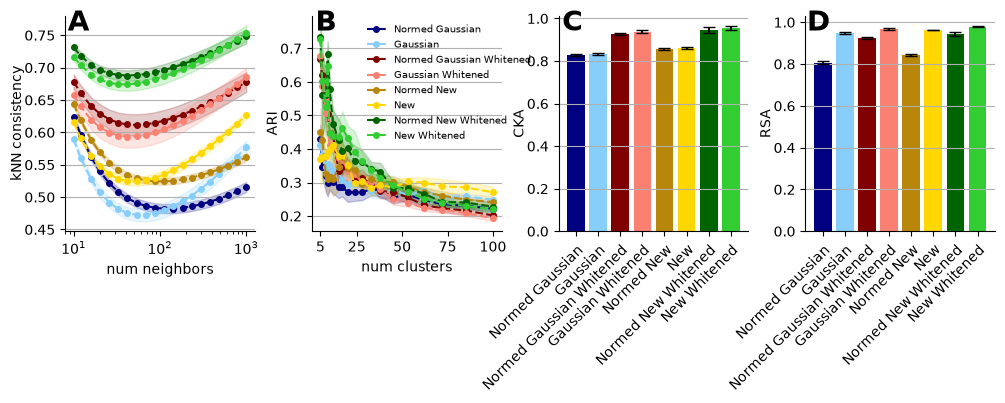

In [12]:
keys = [
    'Normed Gaussian' , 
    'Gaussian' , 
    'Normed Gaussian Whitened', 
    'Gaussian Whitened', 
    'Normed New', 
    'New', 
    'Normed New Whitened', 
    'New Whitened',
]
metric_list = [
    base_metrics, 
    non_base_metrics, 
    base_white_metrics, 
    non_base_white_metrics, 
    new_metrics, 
    non_new_metrics, 
    new_white_metrics,
    non_new_white_metrics,
]
color_list = [
    'navy', 'lightskyblue', 'maroon', 'salmon',
    'darkgoldenrod', 'gold', 'darkgreen', 'limegreen',
]

metrics = {
    metric: {k: m[metric] for k, m in zip(keys, metric_list)}
    for metric in base_metrics.keys()
}
colors = dict(zip(keys, color_list))

plot_knn_ari(metrics, colors, rotation=45, offset=5, ha='right', fontsize=7)

plt.savefig(
    'plots/apx_metrics_norm.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

## chance adjustment

In [13]:
non_base_curve = get_knn_curve(normed_base_readouts, k_range, chance_adjust=False)
non_base_white_curve = get_knn_curve(normed_base_white_readouts, k_range, chance_adjust=False)
non_new_curve = get_knn_curve(normed_new_readouts, k_range, chance_adjust=False)
non_new_white_curve = get_knn_curve(normed_new_white_readouts, k_range, chance_adjust=False)
base_curve = metrics['kNN consistency']['Normed Gaussian']
base_white_curve = metrics['kNN consistency']['Normed Gaussian Whitened']
new_curve = metrics['kNN consistency']['Normed New']
new_white_curve = metrics['kNN consistency']['Normed New Whitened']

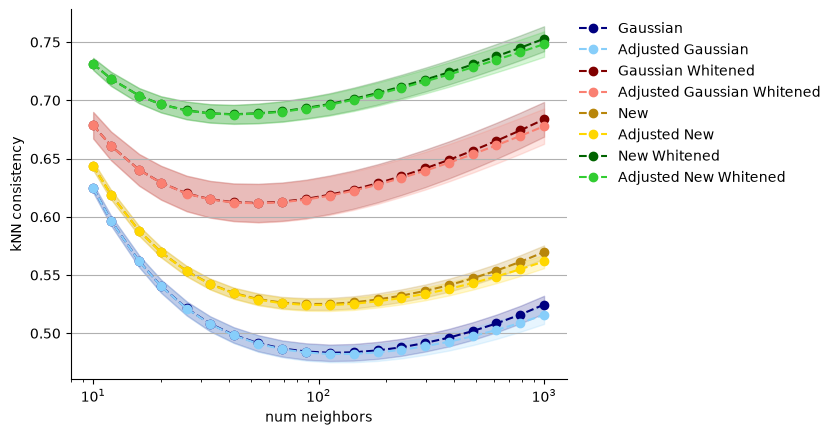

In [14]:
keys = [
    'Gaussian' , 
    'Adjusted Gaussian' , 
    'Gaussian Whitened', 
    'Adjusted Gaussian Whitened', 
    'New', 
    'Adjusted New', 
    'New Whitened',
    'Adjusted New Whitened', 
]
curve_list = [
    non_base_curve, 
    base_curve, 
    non_base_white_curve, 
    base_white_curve, 
    non_new_curve, 
    new_curve, 
    non_new_white_curve,
    new_white_curve,
]
color_list = [
    'navy', 'lightskyblue', 'maroon', 'salmon',
    'darkgoldenrod', 'gold', 'darkgreen', 'limegreen',
]

curves = dict(zip(keys, curve_list))
colors = dict(zip(keys, color_list))

for label, curve in curves.items():
    curve, _ = curve
    m, s = np.array(curve[0]), np.array(curve[1])
    plt.plot(k_range, m, label=label, color=colors[label], linestyle='--', marker='o')
    plt.fill_between(k_range, m - s, m + s, alpha=0.2, color=colors[label])

plt.xlabel('num neighbors')
plt.ylabel('kNN consistency')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y')
plt.xscale('log')
plt.legend(frameon=False, bbox_to_anchor=(1, 1))

plt.savefig(
    'plots/apx_knn_adjust.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# sigma sweep

In [3]:
sigmas = [0, 0.5, 1, 2, 4]
paths = {}
for sigma in sigmas:
    paths[sigma] = [
        f'../training/runs/sigma/{sigma}/sigma{sigma}_seed0',
        f'../training/runs/sigma/{sigma}/sigma{sigma}_seed42',
        f'../training/runs/sigma/{sigma}/sigma{sigma}_seed123',
    ]

models = {}
for sigma, sigma_paths in paths.items():
    sigma_models = []
    for path in sigma_paths:
        model = load_model_from_config(path, dataloaders, device, strict=False)
        sigma_models.append(model)
    models[sigma] = sigma_models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [4]:
from sensorium.utility.scores import get_correlations

means = []
stds = []
for sigma, sigma_models in models.items():
    scores = []
    for model in sigma_models:
        scores.append(
            get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)
        )
    scores = torch.tensor(scores)
    means.append(scores.mean())
    stds.append(scores.std())

In [10]:
num_batches = 5
cache_file = 'data/sigma_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        readouts = pickle.load(f)
else:
    readouts = {}
    for key, sigma_models in models.items():
        readouts[key] = [
            whiten(model, dataloaders['train'], device, num_batches=num_batches, t_readouts=False)
            for model in sigma_models
        ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(readouts, f)

In [23]:
k_range = np.unique(np.geomspace(10, 100, num=10, dtype=int))

curves = {}
for sigma, sigma_readouts in readouts.items():
    curve, _ = get_knn_curve(sigma_readouts, k_range)
    curves[sigma] = curve

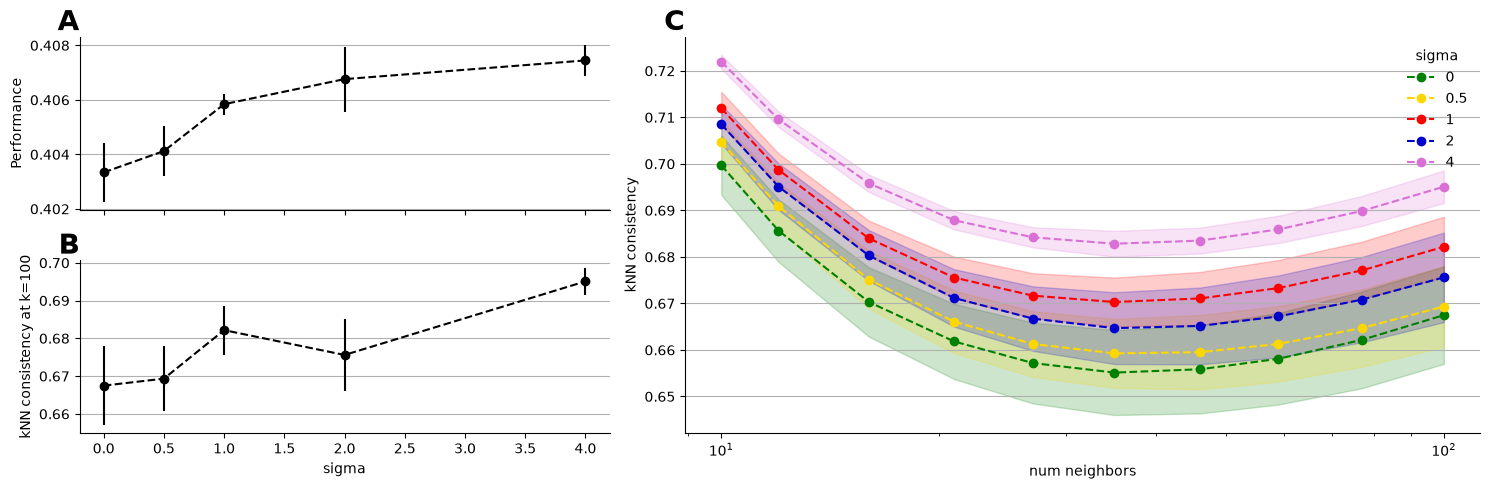

In [34]:
fig = plt.figure(figsize=(15, 5))

gs = fig.add_gridspec(2, 2, width_ratios=[2, 3])

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[1, 0], sharex=ax_a)
ax_c = fig.add_subplot(gs[:, 1])

sigmas = models.keys()
ax = ax_a
ax.errorbar(sigmas, means, yerr=stds, marker='o', linestyle='--', color='black')
ax.set_ylabel('Performance')
ax.label_outer()

ax.text(0.0, 1.0, 'A', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

knn_means = [curve[0][-1] for curve in curves.values()]
knn_stds = [curve[1][-1] for curve in curves.values()]
ax = ax_b
ax.errorbar(sigmas, knn_means, yerr=knn_stds, marker='o', linestyle='--', color='black')
ax.set_xlabel('sigma')
ax.set_ylabel('kNN consistency at k=100')

ax.text(0.0, 1.0, 'B', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

colors = ['green', 'gold', 'red', 'mediumblue', 'orchid']
ax = ax_c
for (sig, curve), color in zip(curves.items(), colors):
    m = curve[0]
    s = curve[1]
    plt.plot(k_range, m, linestyle='--', marker='o', color=color, label=sig)
    plt.fill_between(k_range, m - s, m + s, alpha=0.2, color=color)
ax.set_xscale('log')
ax.set_xlabel('num neighbors')
ax.set_ylabel('kNN consistency')
ax.legend(frameon=False, title='sigma', loc='upper right')
ax.text(0.0, 1.0, 'C', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

for ax in [ax_a, ax_b, ax_c]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y')


plt.tight_layout()
plt.savefig(
    'plots/apx_sigma.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

In [56]:
masks = {}
scores = {}
for sigma, sigma_models in models.items():
    model = sigma_models[0]
    
    masks[sigma] = torch.cat([model.readout[key].spatial.detach().cpu() for key in data_keys])
    
    scores[sigma] = get_correlations(model, dataloaders['validation'], device=device)

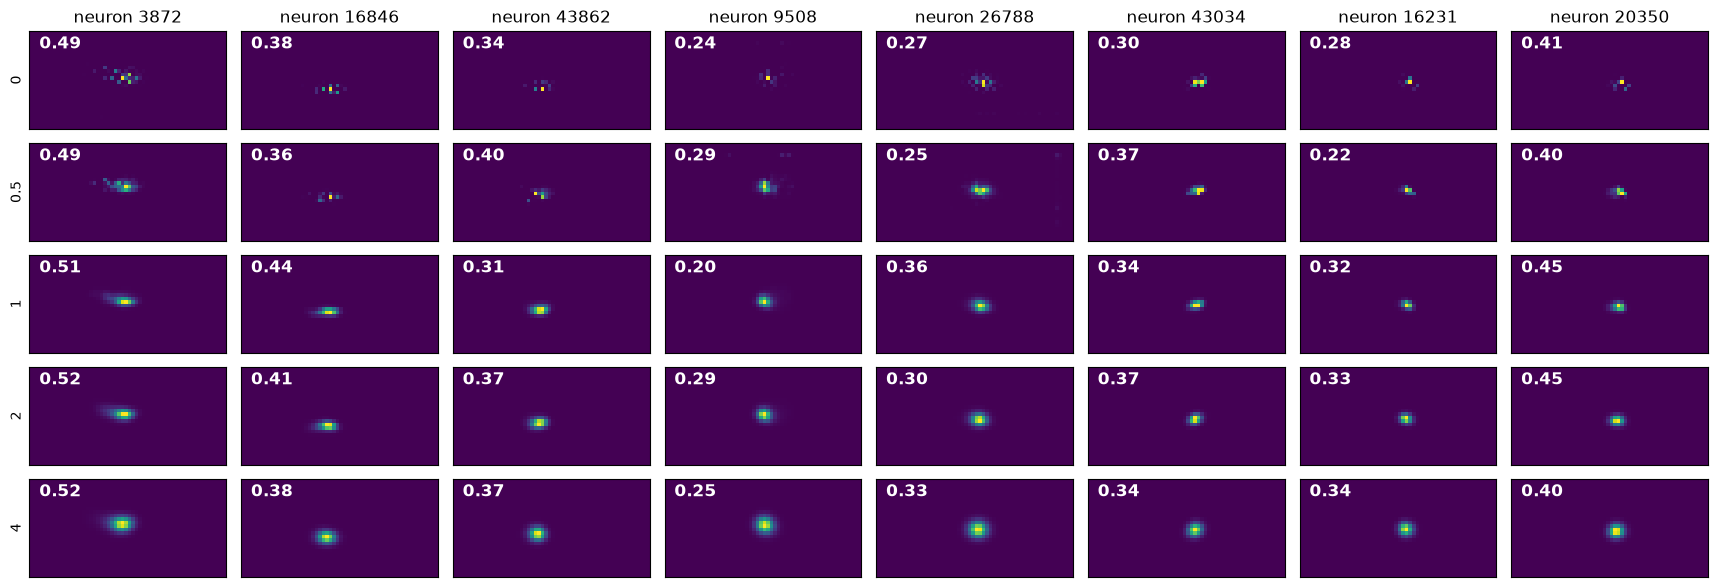

In [60]:
n_neurons = 8
idcs = torch.randperm(masks[list(sigmas)[0]].shape[0])[:n_neurons]

scale = 1.2
fig, axs = plt.subplots(len(sigmas), n_neurons, figsize=(1.8 * scale * n_neurons, scale * len(sigmas)))

for (sigma, sigma_masks), col, sigma_scores in zip(masks.items(), axs, scores.values()):
    for ax, idx in zip(col, idcs):
        ax.imshow(sigma_masks[idx])
        ax.set_xticks([])
        ax.set_yticks([])

        ax.text(
            0.05, 0.95, f'{sigma_scores[idx]:.2f}',
            transform=ax.transAxes,
            color='white',
            fontsize=12,
            ha='left', va='top',
            fontweight='bold',
        )
    
    col[0].set_ylabel(sigma)

for row, idx in zip(axs.T, idcs):
    row[0].set_title(f'neuron {idx}')

plt.tight_layout()

plt.savefig(
    'plots/apx_sigma_masks.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

# reg sweep

In [ ]:
def whiten(model, num_batches=1):
    # load batches and save feature vecs
    features = []
    for key in data_keys:
        batch_features = []
        for i, batch in enumerate(dataloaders['train'][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature.detach().cpu()
            batch_features.append(feature)
        features.append(torch.cat(batch_features))

    X = torch.cat([f.flatten(0, 1) for f in features])
    R = torch.cat([model.readout[k].features.detach().cpu() for k in data_keys])

    # whitening
    mu = X.mean(0, keepdim=True)
    Xc = X - mu
    cov = Xc.T @ Xc / (X.shape[0] - 1)
    
    eye = torch.eye(cov.shape[0])
    L = torch.linalg.cholesky(cov + 1e-5 * eye)
    Rw = R @ L
    return Rw

In [109]:
regs = [1, 2, 3, 5, 7, 10, 30]
nonwhite_paths = {
    0: [
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed0',
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed42',
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed123',
    ],
}
for reg in regs:
    nonwhite_paths[reg] = [
        f'../training/runs/whiten_reg/nonwhiten/reg{reg}/nonwhite_reg{reg}_seed0',
        f'../training/runs/whiten_reg/nonwhiten/reg{reg}/nonwhite_reg{reg}_seed42',
        f'../training/runs/whiten_reg/nonwhiten/reg{reg}/nonwhite_reg{reg}_seed123',
    ]

nonwhite_models = {}
for reg, paths in nonwhite_paths.items():
    models = []
    for path in paths:
        model = load_model_from_config(path, dataloaders, device)
        models.append(model)
    nonwhite_models[reg] = models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [4]:
white_paths = {
    0: [
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed0',
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed42',
        f'../training/runs/whiten_reg/whiten/reg0/white_no_reg_seed123',
    ],
}
for reg in regs:
    white_paths[reg] = [
        f'../training/runs/whiten_reg/whiten/reg{reg}/white_reg{reg}_seed0',
        f'../training/runs/whiten_reg/whiten/reg{reg}/white_reg{reg}_seed42',
        f'../training/runs/whiten_reg/whiten/reg{reg}/white_reg{reg}_seed123',
    ]

white_models = {}
for reg, paths in white_paths.items():
    models = []
    for path in paths:
        model = load_model_from_config(path, dataloaders, device)
        models.append(model)
    white_models[reg] = models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batc

In [5]:
num_batches = 8

cache_file = 'data/reg_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        nonwhite_readouts = pickle.load(f)
else:
    nonwhite_readouts = {}
    for reg, models in nonwhite_models.items():
        nonwhite_readouts[reg] = [whiten(model, num_batches) for model in models]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(nonwhite_readouts, f)

In [6]:
white_readouts = {}
for reg, models in white_models.items():
    readouts = []
    for model in models:
        r = torch.cat([model.readout[key].features.detach() for key in data_keys])
        r = model.whitener.transform_weights(r.T).T.cpu()
        readouts.append(r)
    white_readouts[reg] = readouts

In [22]:
k_range = np.unique(np.geomspace(10, 100, num=10, dtype=int))
nonwhite_knn_means = []
nonwhite_knn_stds = []
for reg, readout in nonwhite_readouts.items():
    curve, _ = get_knn_curve(readout, k_range)
    nonwhite_knn_means.append(curve[0])
    nonwhite_knn_stds.append(curve[1])

In [23]:
white_knn_means = []
white_knn_stds = []
for reg, readout in white_readouts.items():
    curve, _ = get_knn_curve(readout, k_range)
    white_knn_means.append(curve[0])
    white_knn_stds.append(curve[1])

In [9]:
cache_file = 'data/reg_nonwhite_scores.pkl'

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        nonwhite_means, nonwhite_stds = pickle.load(f)
else:
    nonwhite_means = []
    nonwhite_stds = []
    for reg, models in nonwhite_models.items():
        scores = []
        for model in models:
            scores.append(
                get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)
            )
        scores = torch.tensor(scores)
        nonwhite_means.append(scores.mean())
        nonwhite_stds.append(scores.std())
    with open(cache_file, 'wb') as f:
        pickle.dump((nonwhite_means, nonwhite_stds), f)

In [10]:
cache_file = 'data/reg_white_scores.pkl'

if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        white_means, white_stds = pickle.load(f)
else:
    white_means = []
    white_stds = []
    for reg, models in white_models.items():
        scores = []
        for model in models:
            scores.append(
                get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)
            )
        scores = torch.tensor(scores)
        white_means.append(scores.mean())
        white_stds.append(scores.std())
    with open(cache_file, 'wb') as f:
        pickle.dump((white_means, white_stds), f)

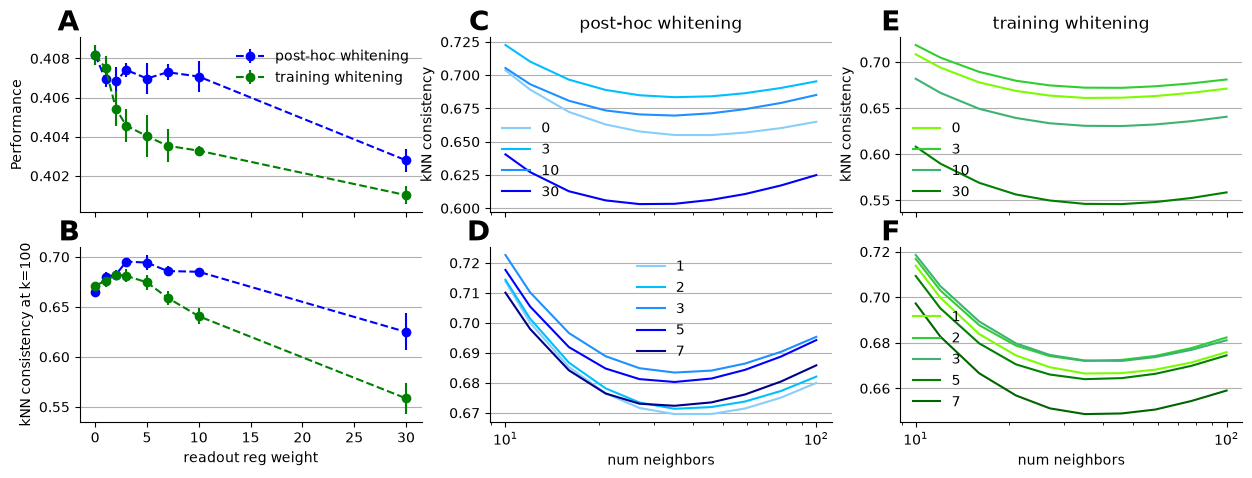

In [70]:
blue_colors = [
    'lightskyblue',
    'deepskyblue',
    'dodgerblue', 
    'blue',      
    'darkblue',  
]

green_colors = [
    'lawngreen',
    'limegreen',
    'mediumseagreen',
    'green',
    'darkgreen',
]

fig, axs = plt.subplots(2, 3, figsize=(15, 5), sharex='col')

ax = axs[0, 0]
ax.errorbar([0] + regs, nonwhite_means, yerr=nonwhite_stds, marker='o', linestyle='--', color=blue_colors[3], label='post-hoc whitening')
ax.errorbar([0] + regs, white_means, yerr=white_stds, marker='o', linestyle='--', color=green_colors[3], label='training whitening')
ax.set_ylabel('Performance')
ax.legend(frameon=False)

ax = axs[1, 0]
m = [curve[-1] for curve in nonwhite_knn_means]
s = [curve[-1] for curve in nonwhite_knn_stds]
ax.errorbar([0] + regs, m, yerr=s, marker='o', linestyle='--', color=blue_colors[3])
m = [curve[-1] for curve in white_knn_means]
s = [curve[-1] for curve in white_knn_stds]
ax.errorbar([0] + regs, m, yerr=s, marker='o', linestyle='--', color=green_colors[3])
ax.set_xlabel('readout reg weight')
ax.set_ylabel('kNN consistency at k=100')


ax = axs[0, 1]
ax.set_title('post-hoc whitening')
ax.set_ylabel('kNN consistency')
for idx, color in zip([0, 3, 6, 7], blue_colors):
    ax.plot(k_range, nonwhite_knn_means[idx], label=([0] + regs)[idx], color=color)
    ax.set_xscale('log')
ax.legend(frameon=False)

ax = axs[1, 1]
ax.set_xlabel('num neighbors')
for idx, color in zip([1, 2, 3, 4, 5], blue_colors):
    ax.plot(k_range, nonwhite_knn_means[idx], label=([0] + regs)[idx], color=color)
    ax.set_xscale('log')
ax.legend(frameon=False)

white_colors = dict(zip([0] + regs, green_shades))

ax = axs[0, 2]
ax.set_title('training whitening')
ax.set_ylabel('kNN consistency')
for idx, color in zip([0, 3, 6, 7], green_colors):
    ax.plot(k_range, white_knn_means[idx], label=([0] + regs)[idx], color=color)
    ax.set_xscale('log')
ax.legend(frameon=False)

ax = axs[1, 2]
ax.set_xlabel('num neighbors')
for idx, color in zip([1, 2, 3, 4, 5], green_colors):
    ax.plot(k_range, white_knn_means[idx], label=([0] + regs)[idx], color=color)
    ax.set_xscale('log')
ax.legend(frameon=False)

for ax, letter in zip(axs.T.flatten(), ['A', 'B', 'C', 'D', 'E', 'F']):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y')

    ax.text(
        0.0, 1.0, letter,
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

plt.savefig(
    'plots/apx_readout_reg.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

In [14]:
k_range = np.unique(np.geomspace(10, 1000, num=20, dtype=int))

knn_means = []
knn_stds = []
for reg, readout in white_readouts.items():
    curve, k_range = get_knn_curve(readout, k_range)
    knn_means.append(curve[0])
    knn_stds.append(curve[1])

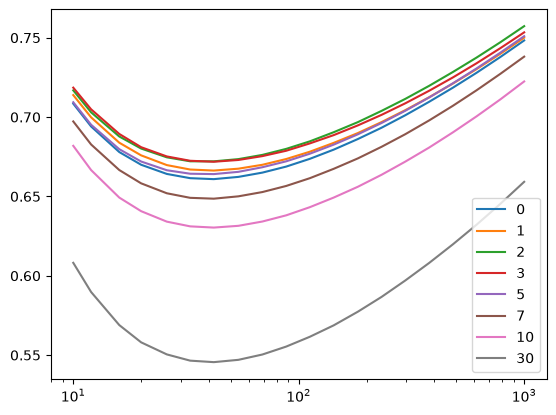

In [22]:
for reg, m, s in zip(
    [0] + regs,
    knn_means,
    knn_stds,
):
    plt.plot(k_range, m, label=reg)
plt.legend()
plt.xscale('log')
plt.show()

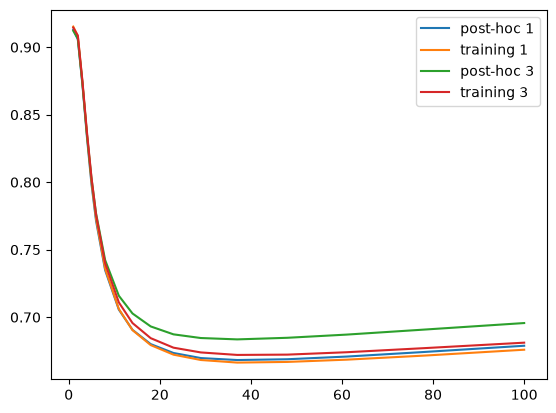

In [10]:
curve, k_range = get_knn_curve(nonwhite_readouts[1])
plt.plot(k_range, curve[0], label='post-hoc 1')
curve, k_range = get_knn_curve(white_readouts[1])
plt.plot(k_range, curve[0], label='training 1')
curve, k_range = get_knn_curve(nonwhite_readouts[3])
plt.plot(k_range, curve[0], label='post-hoc 3')
curve, k_range = get_knn_curve(white_readouts[3])
plt.plot(k_range, curve[0], label='training 3')
plt.legend()

# rand index

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score

def get_ri_curve(all_features, n_clusters_range=None):
    if n_clusters_range is None:
        n_clusters_range = np.unique(np.geomspace(5, 100, num=20, dtype=int))

    def cluster(points, n_clusters):
        kmeans = KMeans(n_clusters=n_clusters, random_state=42)
        labels = kmeans.fit_predict(points)
        return labels
    
    mean_curve = []
    std_curve = []
    for n in n_clusters_range:
        labels = [cluster(features, n) for features in all_features]

        x_idcs, y_idcs = np.tril_indices(len(all_features), k=-1)
        aris = np.array([
            rand_score(labels[x], labels[y]) for x, y in zip(x_idcs, y_idcs)
        ])

        ari_mean = aris.mean()
        ari_std = aris.std(ddof=1)
        mean_curve.append(ari_mean)
        std_curve.append(ari_std)
    
    return (mean_curve, std_curve), n_clusters_range

In [36]:
ri_curve, n_range = get_ri_curve(nonwhite_readouts[3])

In [40]:
ari_curve, n_range = get_ari_curve(nonwhite_readouts[3])

<ErrorbarContainer object of 3 artists>

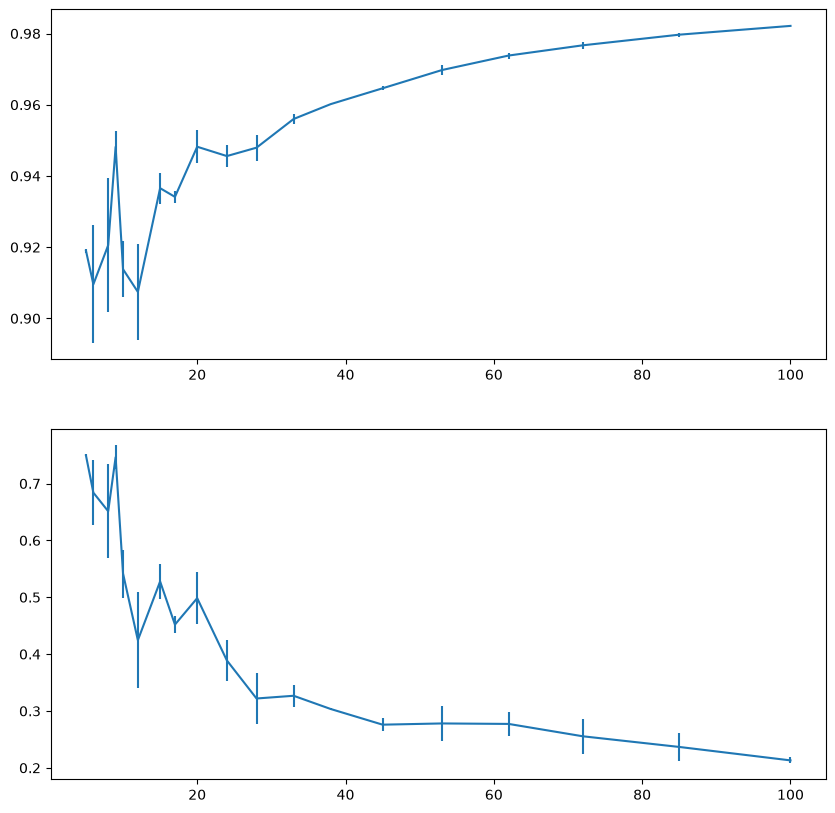

In [41]:
fig, axs = plt.subplots(2, figsize=(10, 10))
m = ri_curve[0]
s = ri_curve[1]
axs[0].errorbar(n_range, m, yerr=s)

m = ari_curve[0]
s = ari_curve[1]
axs[1].errorbar(n_range, m, yerr=s)

# no retinotopy

In [16]:
noretop_paths = [
    '../training/runs/no_retinotopy/no_retinotopy_seed0',
    '../training/runs/no_retinotopy/no_retinotopy_seed42',
    '../training/runs/no_retinotopy/no_retinotopy_seed123',
]
# noretop_paths = [
#     '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed0',
#     '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed42',
#     '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed123',
# ]
noretop_models = [
    load_model_from_config(path, dataloaders, device) for path in noretop_paths
]

retop_paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]
retop_models = [
    load_model_from_config(path, dataloaders, device) for path in retop_paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [17]:
num_batches = 50

In [18]:
noretop_readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in noretop_models
]

cache_file = 'data/noretop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        noretop_white_readouts = pickle.load(f)
else:
    noretop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100) 
        for model in noretop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(noretop_white_readouts, f)

In [19]:
retop_readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in retop_models
]

cache_file = 'data/new_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        retop_white_readouts = pickle.load(f)
else:
    retop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100) 
        for model in new_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(retop_white_readouts, f)

In [20]:
noretop_readouts = [r / r.norm(dim=1, keepdim=True) for r in noretop_readouts]
noretop_white_readouts = [r / r.norm(dim=1, keepdim=True) for r in noretop_white_readouts]
retop_readouts = [r / r.norm(dim=1, keepdim=True) for r in retop_readouts]
retop_white_readouts = [r / r.norm(dim=1, keepdim=True) for r in retop_white_readouts]

In [21]:
k_range = np.unique(np.geomspace(10, 1000, num=20, dtype=int))
n_range = np.unique(np.geomspace(5, 100, num=20, dtype=int))

seeds = [0, 42, 123, 333, 555]
noretop_knn_curve, k_range = get_knn_curve(noretop_readouts, k_range, chance_adjust=True)
noretop_ari_curve, n_range = get_ari_curve(noretop_readouts, n_range, seeds=seeds)
noretop_white_knn_curve, k_range = get_knn_curve(noretop_white_readouts, k_range, chance_adjust=True)
noretop_white_ari_curve, n_range = get_ari_curve(noretop_white_readouts, n_range, seeds=seeds)

retop_knn_curve, k_range = get_knn_curve(retop_readouts, k_range, chance_adjust=True)
retop_ari_curve, n_range = get_ari_curve(retop_readouts, n_range, seeds=seeds)
retop_white_knn_curve, k_range = get_knn_curve(retop_white_readouts, k_range, chance_adjust=True)
retop_white_ari_curve, n_range = get_ari_curve(retop_white_readouts, n_range, seeds=seeds)

In [22]:
retop_performance = np.array([
    get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)
    for model in retop_models
])

noretop_performance = np.array([
    get_correlations(model, dataloaders['validation'], device=device, per_neuron=False)
    for model in noretop_models
])

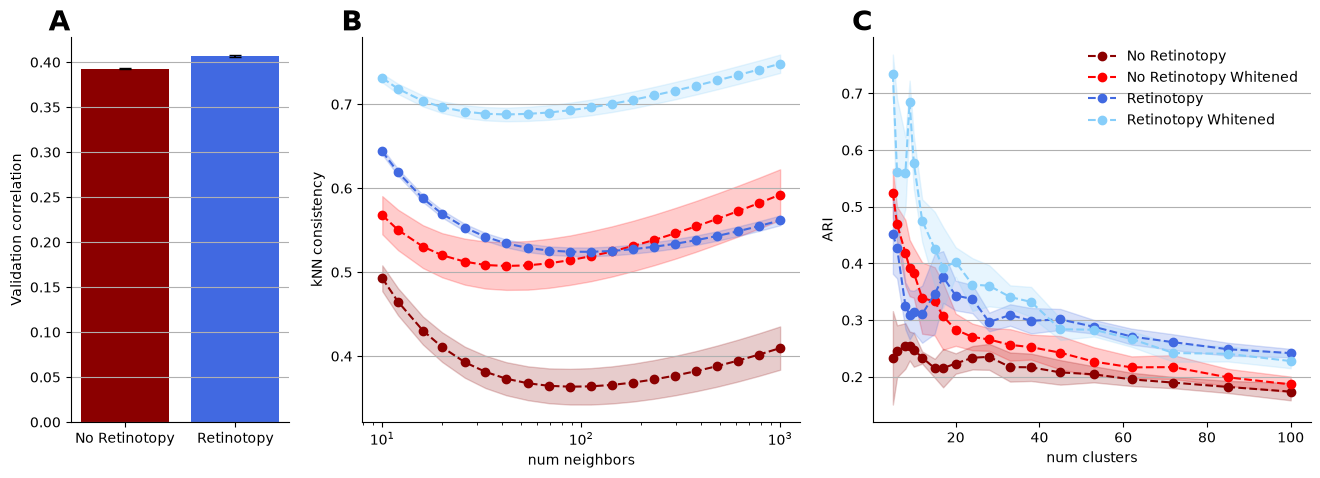

In [24]:
colors = {
    'No Retinotopy': 'darkred',
    'No Retinotopy Whitened': 'red',
    'Retinotopy': 'royalblue',
    'Retinotopy Whitened': 'lightskyblue',
}
performance = {
    'No Retinotopy': (noretop_performance.mean(), noretop_performance.std(ddof=1)),
    'Retinotopy': (retop_performance.mean(), retop_performance.std(ddof=1)),
}
knn_curves = {
    'No Retinotopy': noretop_knn_curve,
    'No Retinotopy Whitened': noretop_white_knn_curve,
    'Retinotopy': retop_knn_curve,
    'Retinotopy Whitened': retop_white_knn_curve,
}
ari_curves = {
    'No Retinotopy': noretop_ari_curve,
    'No Retinotopy Whitened': noretop_white_ari_curve,
    'Retinotopy': retop_ari_curve,
    'Retinotopy Whitened': retop_white_ari_curve,
}

fig, axs = plt.subplots(1, 3, figsize=(16, 5), width_ratios=[1, 2, 2])

def plot_curves(ax, x, curves):
    for label, curve in curves.items():
        m, s = np.array(curve[0]), np.array(curve[1])
        ax.plot(x, m, label=label, color=colors[label], linestyle='--', marker='o')
        ax.fill_between(x, m - s, m + s, alpha=0.2, color=colors[label])

def plot_bar(ax, values, ylabel):
        labels = list(values.keys())
        means = [values[l][0] for l in labels]
        stds = [values[l][1] for l in labels]
        bar_colors = [colors[l] for l in labels]

        ax.bar(labels, means, yerr=stds, color=bar_colors, capsize=4,
               edgecolor=None, linewidth=2, alpha=1)
        ax.set_ylabel(ylabel)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y')
        # ax.set_ylim(0.3)
        # ax.set_xticks(labels)
        # ax.set_xticklabels(labels, rotation=45, rotation_mode='anchor', ha='center')
        # ax.tick_params(axis='x', pad=15)


ax = axs[0]
plot_bar(ax, performance, 'Validation correlation')
ax.text(
    0.0, 1.0, 'A',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)


ax = axs[1]
plot_curves(ax, k_range, knn_curves)
ax.set_xlabel('num neighbors')
ax.set_ylabel('kNN consistency')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y')
ax.set_xscale('log')
ax.text(
    0.0, 1.0, 'B',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

ax = axs[2]
plot_curves(ax, n_range, ari_curves)
ax.set_xlabel('num clusters')
ax.set_ylabel('ARI')
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y')
ax.text(
    0.0, 1.0, 'C',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.savefig(
    'plots/apx_retinotopy.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# RF gradients

In [2]:
paths = [
    '../training/runs/baseline/baseline_seed9',
    '../training/runs/baseline/baseline_seed87',
    '../training/runs/baseline/baseline_seed333',
]

base_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device, strict=False)
    base_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [3]:
paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]
new_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    new_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [34]:
def gradient_com_distance(models, input_shape, device, n_neurons=100):
    im_h, im_w = input_shape[2:]

    neurons = {}
    for key in data_keys:
        total_neurons = max(models[0].readout[key].features.shape)
        neurons[key] = torch.arange(total_neurons)[:n_neurons]

    gradient_coms = []
    for model in models:
        for p in model.parameters():
            p.requires_grad_(False)

        # get gradients
        model_grads = []
        for key in data_keys:
            total_neurons = max(model.readout[key].features.shape)
            img = torch.zeros(*input_shape, requires_grad=True, device=device)
            pred = model(img, data_key=key)

            for i in neurons[key]:
                grad_i, = torch.autograd.grad(
                    pred[0, i], img, retain_graph=True
                )
                model_grads.append(grad_i.detach().cpu().squeeze()[0])

        # compute coms
        rfs = torch.stack(model_grads).abs()
        rfs = rfs / rfs.sum(dim=(1, 2), keepdim=True)
        
        y = rfs.sum(dim=2)  # n, im_h
        x = rfs.sum(dim=1)  # n, im_w

        n = rfs.shape[0]
        y_pos = torch.arange(im_h).unsqueeze(0).expand(n, im_h)
        x_pos = torch.arange(im_w).unsqueeze(0).expand(n, im_w)

        y_avg = (y_pos * y).sum(dim=1)
        x_avg = (x_pos * x).sum(dim=1)

        com = torch.stack([x_avg, y_avg], dim=1)
        gradient_coms.append(com)
        # gradient_coms.append(com.mean(0))

    mean_dists = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        avg_i = gradient_coms[i]
        avg_j = gradient_coms[j]
        dist = (avg_i - avg_j).pow(2).sum(1).sqrt()
        mean_dists.append(dist.mean(0))
        # dist = (avg_i - avg_j).pow(2).sum().sqrt()
        # mean_dists.append(dist)
    return np.array(mean_dists)

In [35]:
input_shape = (1, 4, 36, 64)
h, w = 28, 56

In [36]:
metric_base = gradient_com_distance(base_models, input_shape, device, n_neurons=1000)
metric_new = gradient_com_distance(new_models, input_shape, device, n_neurons=1000)

In [37]:
metric_base, metric_new

(array([1.1420013, 1.2676748, 1.2124467], dtype=float32),
 array([1.1982874, 1.3826145, 1.3834089], dtype=float32))

In [38]:
def compute_gradient_data(models, seeds, key, neuron_ids, input_shape, device, gaussian=True):
    """
    Computes input-gradients and RF locations for a set of models/neurons.

    Returns a dict:
        results[seed][neuron_id] = {
            'grad': tensor (C, H, W),
            'x': float, 'y': float,   # RF center in pixel coords
        }
    """
    results = {}

    for model, seed in zip(models, seeds):
        for param in model.parameters():
            param.requires_grad = False

        if gaussian:
            grid = model.readout[key].sample_grid(1, sample=False).detach().cpu().squeeze()
        else:
            spatial = model.readout[key].spatial.detach().cpu()
            y = spatial.sum(dim=2)  # n, h
            x = spatial.sum(dim=1)  # n, w

            n = spatial.shape[0]
            y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
            x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

            y_avg = (y_pos * y).sum(dim=1)
            x_avg = (x_pos * x).sum(dim=1)
            
            grid = torch.stack([x_avg * 2 / w - 1, y_avg * 2 / h - 1], dim=1)
        

        results[seed] = {}
        for neuron_id in neuron_ids:
            img = torch.zeros(*input_shape, requires_grad=True, device=device)
            pred = model(img, data_key=key)
            pred.squeeze()[neuron_id].backward()
            grad = img.grad.cpu().squeeze()

            x = (grid[neuron_id, 0] + 1) / 2 * w + 4
            y = (grid[neuron_id, 1] + 1) / 2 * h + 4

            results[seed][neuron_id] = {
                'grad': grad[0],
                'x': x.item() if torch.is_tensor(x) else x,
                'y': y.item() if torch.is_tensor(y) else y,
            }

    return results

In [77]:
import matplotlib.patches as patches

def plot_combined_grid(base_results, new_results, seeds,
                        base_neuron_ids, new_neuron_ids,
                        metric_base, metric_new,
                        rf_size=27):
    """
    Combined figure with nested grids:
      outer grid: [ base block | new block | bar plot ]
      base/new blocks: rows = seeds, cols = neurons (nested gridspec)
    """
    n_seeds = len(seeds)
    n_base = len(base_neuron_ids)
    n_new = len(new_neuron_ids)

    fig = plt.figure(figsize=(12, 3))

    outer = fig.add_gridspec(
        nrows=1, ncols=3,
        width_ratios=[n_base, n_new, 1],
        wspace=0.08,
    )

    base_gs = outer[0].subgridspec(n_seeds, n_base, wspace=0.05, hspace=0.05)
    new_gs = outer[1].subgridspec(n_seeds, n_new, wspace=0.05, hspace=0.05)

    def _plot_panel(ax, data, title=None, ylabel=None):
        grad, x, y = data['grad'], data['x'], data['y']
        grad = grad.abs() / grad.abs().sum()

        y_sum = grad.sum(dim=1)  # im_h
        x_sum = grad.sum(dim=0)  # im_w

        im_h, im_w = grad.shape
        y_pos = torch.arange(im_h)
        x_pos = torch.arange(im_w)

        y_avg = (y_pos * y_sum).sum()
        x_avg = (x_pos * x_sum).sum()        

        ax.imshow(grad, vmin=0)
        ax.scatter(x, y, color='red', label='Learned RF')
        ax.scatter(x_avg, y_avg, color='white', marker='x', s=100, label='Gradient COM')
        rect = patches.Rectangle(
            (x - rf_size / 2, y - rf_size / 2),
            rf_size, rf_size,
            linewidth=1.5, edgecolor='red', facecolor='none',
        )
        ax.add_patch(rect)
        ax.set_xticks([])
        ax.set_yticks([])
        if title is not None:
            ax.set_title(title)
        if ylabel is not None:
            ax.set_ylabel(ylabel)

    base_axes = np.empty((n_seeds, n_base), dtype=object)
    for i, seed in enumerate(seeds):
        for j, neuron_id in enumerate(base_neuron_ids):
            ax = fig.add_subplot(base_gs[i, j])
            ylabel = f'seed {seed}' if j == 0 else None
            title = f'Neuron {neuron_id}' if i == 0 else None
            _plot_panel(ax, base_results[seed][neuron_id], title, ylabel)
            base_axes[i, j] = ax

    new_axes = np.empty((n_seeds, n_new), dtype=object)
    for i, seed in enumerate(seeds):
        for j, neuron_id in enumerate(new_neuron_ids):
            ax = fig.add_subplot(new_gs[i, j])
            ylabel = f'seed {seed}' if j == 0 else None
            title = f'Neuron {neuron_id}' if i == 0 else None
            _plot_panel(ax, new_results[seed][neuron_id], title, )#ylabel)
            new_axes[i, j] = ax

    # new_axes[0, -1].legend(frameon=False, labelcolor='white')#, fontsize=12)

    # bar plot spanning full height
    ax_bar = fig.add_subplot(outer[2])
    means = [np.mean(metric_base), np.mean(metric_new)]
    stds = [np.std(metric_base, ddof=1), np.std(metric_new, ddof=1)]
    ax_bar.bar(['Gaussian', 'ReFL'], means, yerr=stds, capsize=4,
               color=['lightskyblue', 'salmon'])
    ax_bar.set_ylabel('Avg COM distance')
    ax_bar.yaxis.set_label_position('right')
    ax_bar.yaxis.tick_right()
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.grid(axis='y')

    fig.canvas.draw()  # finalize layout so positions below are accurate

    # # block titles, centered above each block using actual axes positions
    # def _block_title(axes_row, text):
    #     lefts = [ax.get_position().x0 for ax in axes_row]
    #     rights = [ax.get_position().x1 for ax in axes_row]
    #     top = max(ax.get_position().y1 for ax in axes_row)
    #     cx = (min(lefts) + max(rights)) / 2
    #     fig.text(cx, top + 0.05, text, ha='center', va='bottom',
    #               fontsize=14, fontweight='bold')

    # _block_title(base_axes[0, :], 'Gaussian')
    # _block_title(new_axes[0, :], 'New')
    
    ax = base_axes[0, 0]
    ax.text(0.0, 1.0, 'A', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')
    ax = new_axes[0, 0]
    ax.text(0.0, 1.0, 'B', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')
    ax = ax_bar
    ax.text(0.0, 1.0, 'C', transform=ax.transAxes, fontsize=20, fontweight='bold', va='bottom', ha='right')

    return fig

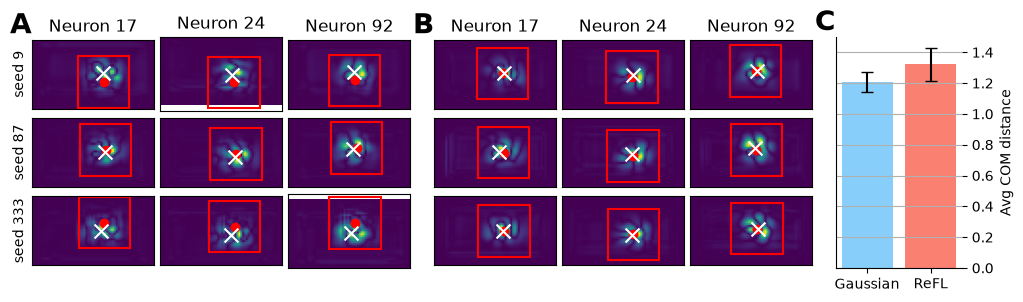

In [87]:
key = data_keys[6]
seeds = [9, 87, 333]

o = 102
base_neuron_ids = [0 + o, 1 + o, 2 + o]
new_neuron_ids = [0 + o, 1 + o, 2 + o]
# # 17 24 32 62 76 89 92 102 103
base_neuron_ids = [17, 24, 92]
new_neuron_ids = [17, 24, 92]

base_results = compute_gradient_data(base_models, seeds, key, base_neuron_ids, input_shape, device)
new_results = compute_gradient_data(new_models, seeds, key, new_neuron_ids, input_shape, device, gaussian=False)

fig = plot_combined_grid(base_results, new_results, seeds,
                          base_neuron_ids, new_neuron_ids,
                          metric_base, metric_new)

plt.savefig(
    'plots/results_gradients.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# cka on cores

In [60]:
paths = [
    '../training/runs/baseline/baseline_seed9',
    '../training/runs/baseline/baseline_seed87',
    '../training/runs/baseline/baseline_seed333',
]

base_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device, strict=False)
    base_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [61]:
paths = [
    '../training/runs/whiten_reg/whiten/reg3/white_reg3_seed0',
    '../training/runs/whiten_reg/whiten/reg3/white_reg3_seed42',
    '../training/runs/whiten_reg/whiten/reg3/white_reg3_seed123',
]
new_models = []
for path in paths:
    model = load_model_from_config(path, dataloaders, device)
    new_models.append(model)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [66]:
model = base_models[0]

In [167]:
def get_features_mean(model, num_batches=5, gaussian=True):
    features = []
    for key in data_keys:
        if gaussian:
            grid = model.readout[key].sample_grid(1, sample=False).detach().squeeze()
        else:
            spatial = model.readout[key].spatial.detach()
            y = spatial.sum(dim=2)  # n, h
            x = spatial.sum(dim=1)  # n, w

            n = spatial.shape[0]
            y_pos = torch.arange(h, device=device).unsqueeze(0).expand(n, h)
            x_pos = torch.arange(w, device=device).unsqueeze(0).expand(n, w)

            y_avg = (y_pos * y).sum(dim=1)
            x_avg = (x_pos * x).sum(dim=1)
            
            grid = torch.stack([x_avg * 2 / w - 1, y_avg * 2 / h - 1], dim=1)

        mean = grid.mean(0)[None, None, None, :].expand(dataset_config['batch_size'], 1, 1, 2)

        batch_features = []
        for i, batch in enumerate(dataloaders['validation'][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)

            feature_map = model.core(img)
            feature = torch.nn.functional.grid_sample(
                feature_map, 
                mean[:feature_map.shape[0]], 
                align_corners=True
            ).squeeze().detach().cpu()

            batch_features.append(feature)
        features.append(torch.cat(batch_features))

    features = torch.cat(features)
    return features

In [208]:
def get_features_specific(model, num_batches=5):
    features = []
    for key in data_keys:
        dist_sq = model.readout[key].source_grid.cpu().pow(2).sum(1)
        neuron_id = dist_sq.argmin()
        print(neuron_id)

        batch_features = []
        for i, batch in enumerate(dataloaders['validation'][key]):
            if i == num_batches:
                break

            img, target, behav = batch[:3]
            img = img.to(device)
            
            if len(batch) == 4:
                pupil = batch[3]
                pupil = pupil.to(device)
            elif len(batch) == 3:
                pupil = None

            pred, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
            feature = feature[:, neuron_id, :].detach().cpu()
            batch_features.append(feature)
        features.append(torch.cat(batch_features))

    features = torch.cat(features)
    return features

In [209]:
def cka(features):
    ckas = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        X, Y = features[i], features[j]

        Xc = X - X.mean(0, keepdim=True)
        Yc = Y - Y.mean(0, keepdim=True)

        XT_Y = Xc.T @ Yc
        XT_X = Xc.T @ Xc
        YT_Y = Yc.T @ Yc

        numerator = torch.norm(XT_Y, p='fro') ** 2
        denominator_x = torch.norm(XT_X, p='fro')
        denominator_y = torch.norm(YT_Y, p='fro')

        cka = numerator / (denominator_x * denominator_y)
        ckas.append(cka)
    ckas = torch.tensor(ckas)
    mean = ckas.mean()
    std = ckas.std()
    return mean, std

In [210]:
base_features = [get_features_mean(model, gaussian=True) for model in base_models]
cka(base_features)

(tensor(0.8893), tensor(0.0039))

In [211]:
new_features = [get_features_mean(model, gaussian=False) for model in new_models]
cka(new_features)

(tensor(0.8644), tensor(0.0081))

In [213]:
base_features = [get_features_specific(model) for model in base_models]
cka(base_features)

tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)
tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)
tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)


(tensor(0.8844), tensor(0.0048))

In [215]:
new_features = [get_features_specific(model) for model in new_models]
cka(new_features)

tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)
tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)
tensor(5020)
tensor(2598)
tensor(5066)
tensor(4417)
tensor(2551)
tensor(6077)
tensor(6235)


(tensor(0.9182), tensor(0.0075))

# mask visualizations

In [2]:
path = '../training/runs/whiten_reg/whiten/reg3/white_reg3_seed0'
new_model = load_model_from_config(path, dataloaders, device)

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")


In [3]:
weights = []
biases = []
for key in data_keys:
    readout = new_model.readout[key]

    weight = readout.spatial_w.detach().cpu()
    bias = readout.spatial_b.detach().cpu()

    kernel = readout.gaussian_kernel(device).cpu()
    weight = readout.smooth(weight, kernel)
    bias = readout.smooth(bias, kernel).cpu()
    weights.append(weight)
    biases.append(bias)

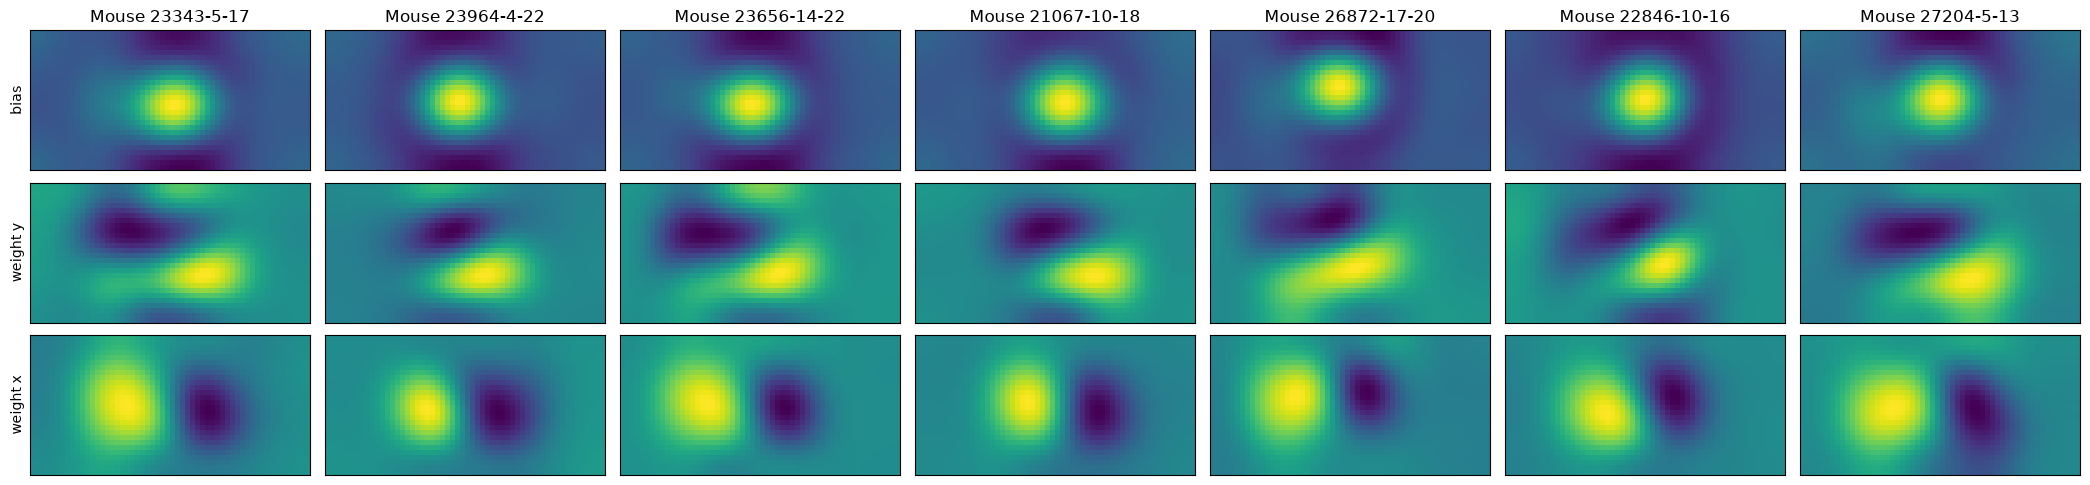

In [11]:
num_mice = 7
fig, axs = plt.subplots(3, num_mice, figsize=(num_mice * 9/3, 5))

for i in range(num_mice):
    col = axs[:, i]
    col[0].imshow(biases[i][0])
    col[1].imshow(weights[i][0])
    col[2].imshow(weights[i][1])

    col[0].set_title(f'Mouse {data_keys[i]}')

axs[0, 0].set_ylabel('bias')
axs[1, 0].set_ylabel('weight y')
axs[2, 0].set_ylabel('weight x')

for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()

plt.savefig(
    'plots/apx_spatial_weights.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

In [12]:
scores = get_correlations(new_model, dataloaders['validation'], device=device)

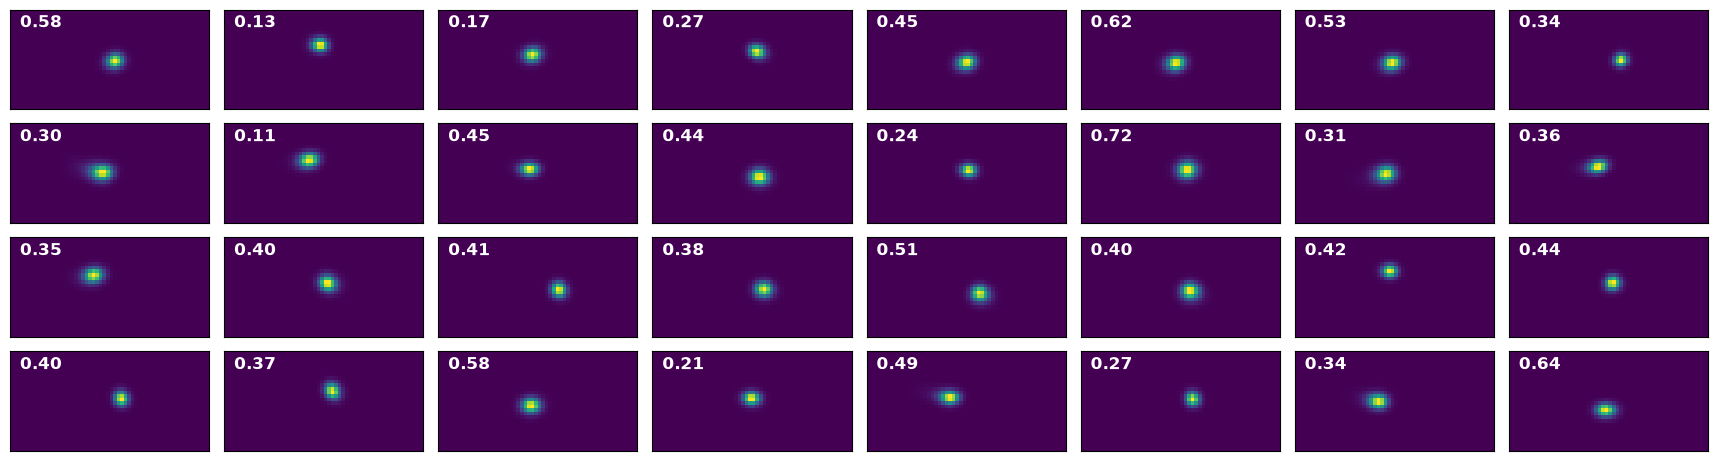

In [32]:
masks = torch.cat([new_model.readout[key].spatial.detach().cpu() for key in data_keys])

m, n = 4, 8
n_neurons = m * n
idcs = torch.randperm(masks.shape[0])[:n_neurons]

scale = 1.2
fig, axs = plt.subplots(m, n, figsize=(1.8 * scale * n, scale * m))

for i, idx in enumerate(idcs):
    ax = axs[i % m, i // m]
    ax.imshow(masks[idx])
    ax.text(
        0.05, 0.95, f'{scores[idx]:.2f}',
        transform=ax.transAxes,
        color='white',
        fontsize=12,
        ha='left', va='top',
        fontweight='bold',
    )
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()


plt.savefig(
    'plots/apx_masks.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

# baseline improvements

In [2]:
options = ['mlp', 'lin']

base_paths = {}
for grid in options:
    for shift in options:
        base_paths[f'{grid}-{shift}'] = [
            f'../training/runs/baseline/{grid}_grid_{shift}_shift/baseline_{grid}_{shift}_seed9',
            f'../training/runs/baseline/{grid}_grid_{shift}_shift/baseline_{grid}_{shift}_seed87',
            f'../training/runs/baseline/{grid}_grid_{shift}_shift/baseline_{grid}_{shift}_seed333',
        ]

base_models = {}
for key, paths in base_paths.items():
    models = []
    for path in paths:
        model = load_model_from_config(path, dataloaders, device)
        models.append(model)
    base_models[key] = models

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [4]:
scores = {}
for key, models in base_models.items():
    key_scores = []
    for model in models:
        key_scores.append(get_correlations(model, dataloaders['validation'], device=device, per_neuron=False))
    scores[key] = key_scores

In [5]:
num_batches = 5
cache_file = 'data/baseline_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        readouts = pickle.load(f)
else:
    readouts = {}
    for key, models in base_models.items():
        readouts[key] = [
            whiten(model, dataloaders['train'], device, num_batches=num_batches, t_readouts=True) 
            for model in models
        ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(readouts, f)

In [6]:
k_range = np.unique(np.geomspace(10, 1000, num=20, dtype=int))

curves = []
for _, readout in readouts.items():
    curve, _ = get_knn_curve(readout, k_range)
    curves.append(curve)

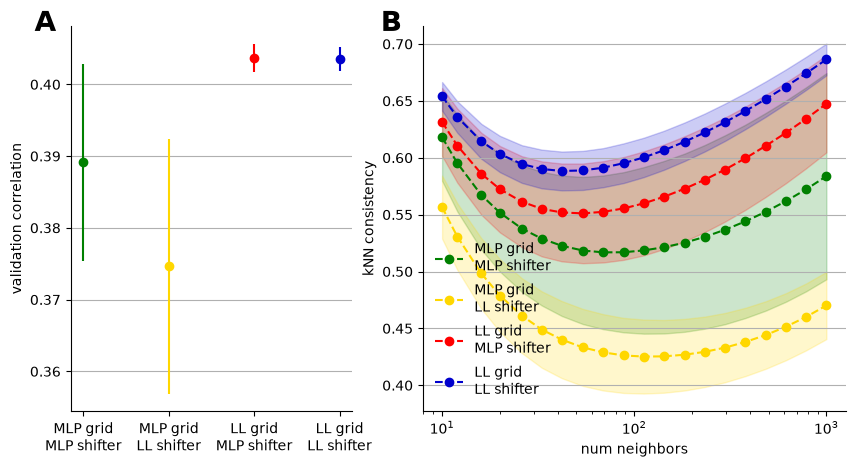

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [2, 3]})

labels = ['MLP grid\nMLP shifter', 'MLP grid\nLL shifter', 'LL grid\nMLP shifter', 'LL grid\nLL shifter']
colors = ['green', 'gold', 'red', 'mediumblue']

ax = axs[0]
for x, key_scores, color in zip(range(4), scores.values(), colors):
    m = np.mean(key_scores)
    s = np.std(key_scores, ddof=1)
    ax.errorbar([x], [m], yerr=[s], marker='o', color=color)
ax.set_xticks(ticks=[0, 1, 2, 3], labels=labels)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('validation correlation')
ax.grid(axis='y')
ax.text(
    -0.05, 0.97, 'A',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

ax = axs[1]
for label, curve, color in zip(labels, curves, colors):
    m = curve[0]
    s = curve[1]
    ax.plot(k_range, m, color=color, linestyle='--', marker='o', label=label)
    ax.fill_between(k_range, m - s, m + s, alpha=0.2, color=color)
ax.set_xlabel('num neighbors')
ax.set_ylabel('kNN consistency')
ax.set_xscale('log')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y')
ax.legend(frameon=False, loc='lower left')
ax.text(
    -0.05, 0.97, 'B',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

plt.savefig(
    'plots/apx_baseline_improvement.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

In [87]:
def plot_baseline_rf_grids(mice=[0, 1, 2, 3, 4, 5, 6], figsize=(18, 9), n_neurons=None):
    fig = plt.figure(figsize=figsize)

    mice = np.array(mice)

    gs = fig.add_gridspec(
        2 + len(model_types), len(mice),
        height_ratios=[1, 1, 2, 2, 2, 2],
        hspace=0.3,
        wspace=0.05,
    )

    # Two metric axes, each spanning all 4 columns
    ax_performance = fig.add_subplot(gs[0, :])
    ax_metric = fig.add_subplot(gs[1, :])

    # Bottom: 2 x 4 grid of point plots
    axs = np.empty((len(model_types), len(mice)), dtype=object)

    for row in range(len(model_types)):
        for col in range(len(mice)):
            axs[row, col] = fig.add_subplot(gs[row + 2, col])

    model_colors = {
        "mlp-mlp": ['darkolivegreen', 'yellowgreen', 'lime'],
        "mlp-lin": ['maroon', 'red', 'lightsalmon'],
        "lin-mlp": ['saddlebrown', 'gold', 'yellow'],
        "lin-lin": ['indigo', 'darkviolet', 'plum'],
    }
    labels = {
        'mlp-mlp': 'MLP-MLP',
        'mlp-lin': 'MLP-LL',
        'lin-mlp': 'LL-MLP',
        'lin-lin': 'LL-LL',
    }

    for ax, metric_name, metric_data in [
        (ax_performance, "Performance", performance),
        (ax_metric, "RF Distance", metric),
    ]:

        offsets = [-0.3, -0.1, 0.1, 0.3]
        for model_idx, (type_name, values) in enumerate(metric_data.items()):

            # values: [seed, mouse]
            values = np.asarray(values)

            means = values.mean(axis=0)
            stds = values.std(axis=0, ddof=1)

            x = np.arange(len(mice)) + offsets[model_idx]
            
            ax.errorbar(
                x,
                means[mice],
                yerr=stds[mice],
                fmt='o',
                # capsize=4,
                # capthick=2,
                linewidth=2,
                label=labels[type_name],
                color=model_colors[type_name][1],
            )

        ax.set_xticks([])
        margin = 0.46
        ax.set_xlim(0 - margin, len(mice) - 1 + margin)

        ax.set_ylabel(metric_name)

        ax.spines['top'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(axis='y')


    for row_idx, (type_name, grids) in enumerate(model_types.items()):
        for i, mouse_idx in enumerate(mice):
            ax = axs[row_idx, i]
            if n_neurons is not None:
                idcs = torch.randperm(grids[0][mouse_idx].shape[0])[:n_neurons]
            else:
                idcs = torch.arange(grids[0][mouse_idx].shape[0])

            for model_idx in range(num_models):
                grid = grids[model_idx][mouse_idx]
                ax.scatter(
                    grid[idcs, 0],
                    grid[idcs, 1],
                    alpha=1.0,
                    s=0.1,
                    color=model_colors[type_name][model_idx],
                    label=f"seed {model_seeds[model_idx]}",
                )

            ax.set_aspect('equal')
    
            for spine in ax.spines.values():
                spine.set_visible(False)

            ax.set_xticks([])
            ax.set_yticks([])
            
            if i == 0:
                ax.set_ylabel(labels[type_name], rotation=90)

    ax_metric.legend(frameon=False, loc='upper right', bbox_to_anchor=(1.0, 2.0))

    handles, labels = axs[0, 0].get_legend_handles_labels()
    axs[0, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 1.8),
        loc='upper right',
        markerscale=20,
        frameon=False,
    )
    
    handles, labels = axs[1, 0].get_legend_handles_labels()
    axs[1, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 4.0),
        loc='upper right',
        markerscale=20,
        frameon=False,
    )

    handles, labels = axs[2, 0].get_legend_handles_labels()
    axs[2, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 1.7),
        loc='upper right',
        markerscale=20,
        frameon=False,
    )

    handles, labels = axs[3, 0].get_legend_handles_labels()
    axs[3, -1].legend(
        handles,
        labels,
        bbox_to_anchor=(1.0, 1.7),
        loc='upper right',
        markerscale=20,
        frameon=False,
    )

    for i in range(len(mice)):
        ax = axs[0, i]
        bbox = ax.get_position()

        fig.text(
            bbox.x0 + bbox.width / 2,
            0.92,
            f"Mouse {data_keys[mice[i]]}",
            ha="center",
            va="top",
        )

    ax_performance.text(
        0.0, 1.0, 'A',
        transform=ax_performance.transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

    ax_metric.text(
        0.0, 1.0, 'B',
        transform=ax_metric.transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

    axs[0, 0].text(
        0.0, 1.2, 'C',
        transform=axs[0, 0].transAxes,
        fontsize=20,
        fontweight='bold',
        va='bottom',
        ha='right',
    )

In [39]:
h, w = 28, 56
model_types = {}
for model_key, models in base_models.items():
    base_grids = []
    for model in models:
        grids = []
        for key in data_keys:
            grid = model.readout[key].sample_grid(1, sample=False).squeeze().detach().cpu()
            grid[:, 0] = (grid[:, 0] + 1) / 2 * w
            grid[:, 1] = (grid[:, 1] + 1) / 2 * h
            grid = grid - grid.mean(0, keepdim=True)

            grids.append(grid)
        base_grids.append(grids)
    model_types[model_key] = base_grids

In [43]:
metric = {}
for type_name, grids in model_types.items():
    model_avgs = []
    for i, j in [[0, 1], [0, 2], [1, 2]]:
        # print(grids[0].shape)
        avgs = []
        for animal in range(7):
            d = (grids[i][animal] - grids[j][animal]).pow(2).sum(1).sqrt()
            avg = d.mean()
            avgs.append(avg)
            # print(f'between seeds: {model_seeds[i]}, {model_seeds[j]}: {avg} pixels')
        model_avgs.append(avgs)
    metric[type_name] = model_avgs

In [45]:
performance = {}
for model_key, models in base_models.items():
    base_scores = []
    for model in models:
        model_scores = get_correlations(model, dataloaders['validation'], device=device, as_dict=True)
        model_scores = [v.mean() for v in model_scores.values()]
        base_scores.append(model_scores)
    performance[model_key] = base_scores

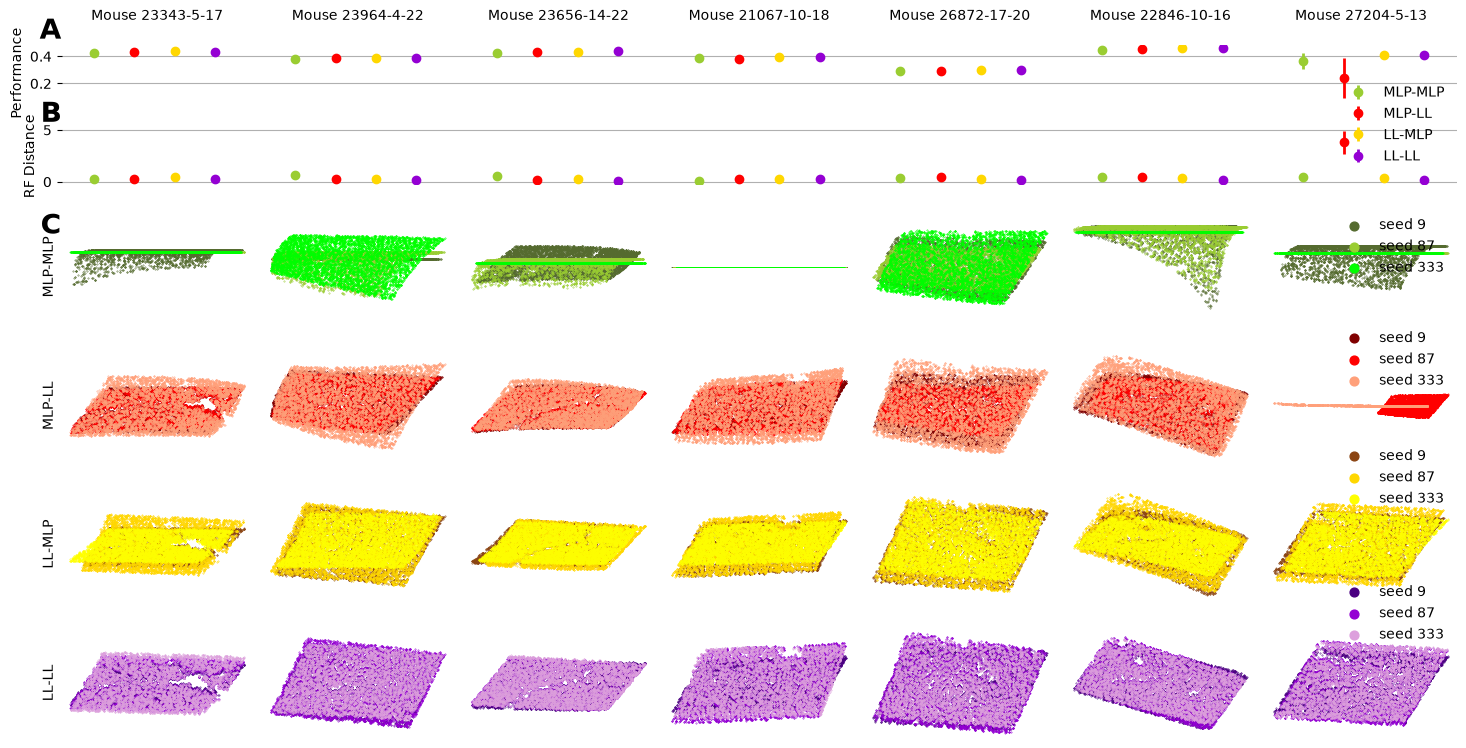

In [89]:
num_models = 3
model_seeds = [9, 87, 333]
plot_baseline_rf_grids()

plt.savefig(
    'plots/apx_baseline_grids.png',
    dpi=200,
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# cortex embedding correlation

In [2]:
base_noretop_paths = [
    '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed0',
    '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed42',
    '../training/runs/baseline/no_retinotopy/baseline_no_retinotopy_seed123',
]
base_noretop_models = [
    load_model_from_config(path, dataloaders, device) for path in base_noretop_paths
]

new_noretop_paths = [
    '../training/runs/no_retinotopy/no_retinotopy_seed0',
    '../training/runs/no_retinotopy/no_retinotopy_seed42',
    '../training/runs/no_retinotopy/no_retinotopy_seed123',
]
new_noretop_models = [
    load_model_from_config(path, dataloaders, device) for path in new_noretop_paths
]

base_retop_paths = [
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed9',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed87',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed333',
]
base_retop_models = [
    load_model_from_config(path, dataloaders, device) for path in base_retop_paths
]

new_retop_paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]
new_retop_models = [
    load_model_from_config(path, dataloaders, device) for path in new_retop_paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
P

In [3]:
num_batches = 50

In [4]:
base_noretop_readouts = [
    torch.cat([model.readout[k].features.squeeze().T.detach().cpu() for k in data_keys])
    for model in base_noretop_models
]

cache_file = 'data/base_noretop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        base_noretop_white_readouts = pickle.load(f)
else:
    base_noretop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=True, n_subsample=100, as_dict=True) 
        for model in base_noretop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(base_noretop_white_readouts, f)

In [5]:
new_noretop_readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in new_noretop_models
]

cache_file = 'data/new_noretop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        new_noretop_white_readouts = pickle.load(f)
else:
    new_noretop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100, as_dict=True) 
        for model in new_noretop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(new_noretop_white_readouts, f)

In [6]:
base_retop_readouts = [
    torch.cat([model.readout[k].features.squeeze().T.detach().cpu() for k in data_keys])
    for model in base_retop_models
]

cache_file = 'data/base_retop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        base_retop_white_readouts = pickle.load(f)
else:
    base_retop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=True, n_subsample=100, as_dict=True) 
        for model in base_retop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(base_retop_white_readouts, f)

In [7]:
new_retop_readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in new_retop_models
]

cache_file = 'data/new_retop_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        new_retop_white_readouts = pickle.load(f)
else:
    new_retop_white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100, as_dict=True) 
        for model in new_retop_models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(new_retop_white_readouts, f)

In [8]:
base_noretop_readouts = [
    {k: r / r.norm(dim=1, keepdim=True) for k, r in readouts.items()}
    for readouts in base_noretop_white_readouts
]
new_noretop_readouts = [
    {k: r / r.norm(dim=1, keepdim=True) for k, r in readouts.items()}
    for readouts in new_noretop_white_readouts
]
base_retop_readouts = [
    {k: r / r.norm(dim=1, keepdim=True) for k, r in readouts.items()}
    for readouts in base_retop_white_readouts
]
new_retop_readouts = [
    {k: r / r.norm(dim=1, keepdim=True) for k, r in readouts.items()}
    for readouts in new_retop_white_readouts
]

## pca

In [11]:
# global PCA

grids = {}
colors = {}

X = torch.cat(list(readouts.values()))
Xc = X - X.mean(0)

U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
explained_var_ratio = (S**2) / (S**2).sum()

k = 3
Z = Xc @ Vt[:k].T
color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))

offset = 0
for key in data_keys:
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs + offset] for idcs in idcs_by_layer]
    
    grids[key] = cords_by_layer
    colors[key] = color_by_layer
    
    offset += grid.shape[0]

In [6]:
# per animal PCA

grids = {}
colors = {}

X = torch.cat(list(readouts.values()))

for key, readout in readouts.items():
    X = readout
    Xc = X - X.mean(0)

    U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
    explained_var_ratio = (S**2) / (S**2).sum()

    k = 3
    Z = Xc @ Vt[:k].T
    color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))

    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs] for idcs in idcs_by_layer]
    
    grids[key] = cords_by_layer
    colors[key] = color_by_layer

In [9]:
# per layer PCA

grids = {}
colors = {}

X = torch.cat(list(readouts.values()))

for key, readout in readouts.items():
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates
    
    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = []
    for idcs in idcs_by_layer:
        X = readout[idcs]
        Xc = X - X.mean(0)

        U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)
        explained_var_ratio = (S**2) / (S**2).sum()

        k = 3
        Z = Xc @ Vt[:k].T
        color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))
        color_by_layer.append(color)
        
    grids[key] = cords_by_layer
    colors[key] = color_by_layer

## tsne

In [34]:
# global UMAP (3D, scales fine to 50k points)
import umap

grids = {}
colors = {}

X = torch.cat(list(readouts.values()))
Xc = X - X.mean(0)
Xc_np = Xc.numpy()

k = 3
reducer = umap.UMAP(
    n_components=k,
    n_neighbors=15,   # lower = more local focus, higher = more global
    min_dist=0.1,
    # random_state=0,
)
Z = torch.from_numpy(reducer.fit_transform(Xc_np))

def robust_normalize(Z, low=1, high=99):
    lo = torch.quantile(Z, low / 100, dim=0)
    hi = torch.quantile(Z, high / 100, dim=0)
    Zc = (Z - lo) / (hi - lo)
    return Zc.clamp(0, 1)

color = robust_normalize(Z)
# color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))

offset = 0
for key in data_keys:
    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs + offset] for idcs in idcs_by_layer]
    grids[key] = cords_by_layer
    colors[key] = color_by_layer
    offset += grid.shape[0]

In [24]:
# per animal UMAP
import umap

grids = {}
colors = {}

for key, readout in readouts.items():
    X = readout
    Xc = X - X.mean(0)
    Xc_np = Xc.numpy()

    k = 3
    reducer = umap.UMAP(
        n_components=k,
        n_neighbors=15,   # lower = more local focus, higher = more global
        min_dist=0.1,
        # random_state=0,
    )
    Z = torch.from_numpy(reducer.fit_transform(Xc_np))
    color = (Z - Z.amin(0)) / (Z.amax(0) - Z.amin(0))

    grid = dataloaders['train'][key].dataset.neurons.cell_motor_coordinates

    depths = grid[:, 2]
    unique = np.unique(depths)
    idcs_by_layer = [np.where(depths == d)[0] for d in unique]
    cords_by_layer = [grid[idcs, :2] for idcs in idcs_by_layer]

    color_by_layer = [color[idcs] for idcs in idcs_by_layer]
    grids[key] = cords_by_layer
    colors[key] = color_by_layer

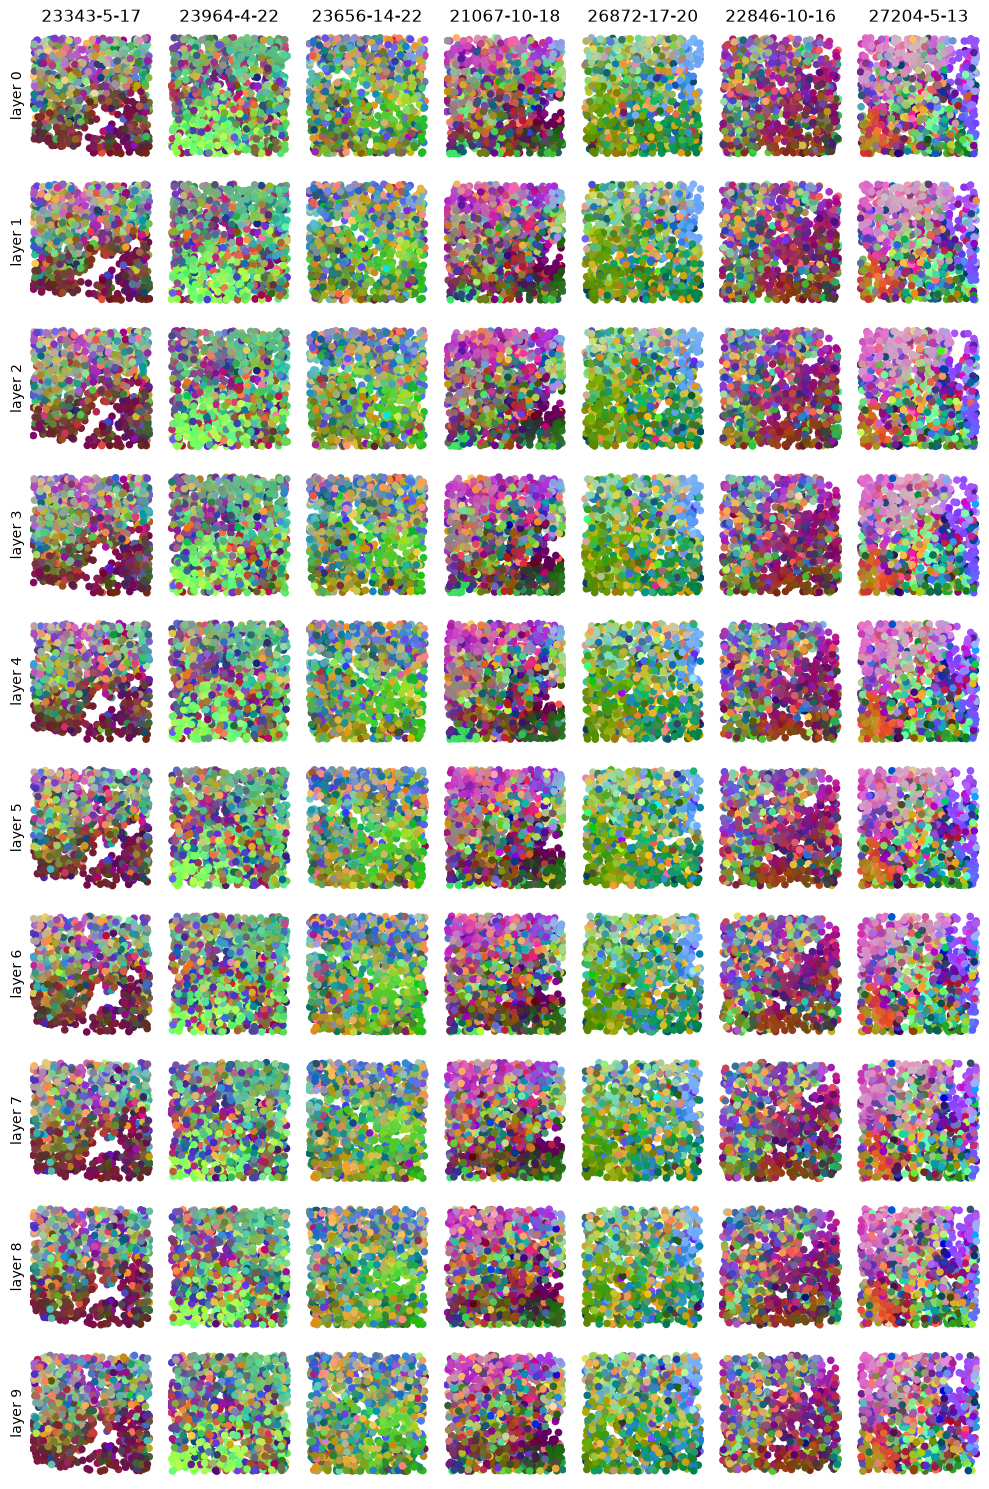

In [35]:
fig, axs = plt.subplots(len(grids[data_keys[0]]), len(grids), figsize=(10, 15))

for i, key in enumerate(data_keys):
    for j, (cords, color) in enumerate(zip(grids[key], colors[key])):
        ax = axs[j, i]
        ax.scatter(cords[:, 0], cords[:, 1], c=color, s=20)
        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spines in ax.spines.values():
            spines.set_visible(False)

        if i == 0:
            ax.set_ylabel(f'layer {j}')
        if j == 0:
            ax.set_title(key)
            

plt.tight_layout()
plt.show()

## spearman plot

In [12]:
types = {
    'Gaussian no retinotopy': base_noretop_readouts,
    'Gaussian': base_retop_readouts,
    'ReFL no retinotopy': new_noretop_readouts,
    'ReFL': new_retop_readouts,
}
cache_file = 'data/spearman_emb.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        results = pickle.load(f)
else:
    results = {model_type: {} for model_type in types}  # results[model_type][key] = (mean, std)

    for model_type, readouts in types.items():
        for key in data_keys:
            grid = torch.from_numpy(dataloaders['train'][key].dataset.neurons.cell_motor_coordinates[:, :2])
            cortex_dists = (grid[:, None] - grid[None, :]).pow(2).sum(-1).sqrt()

            corrs = []
            for seed_nr in range(3):
                readout = readouts[seed_nr][key]
                readout_dists = (readout[:, None] - readout[None, :]).pow(2).sum(-1).sqrt()

                n = grid.shape[0]
                i, j = torch.tril_indices(n, n, offset=-1)
                x = cortex_dists[i, j]
                y = readout_dists[i, j]

                x_rank = torch.argsort(torch.argsort(x)).to(torch.float64)
                y_rank = torch.argsort(torch.argsort(y)).to(torch.float64)

                xc = x_rank - x_rank.mean()
                yc = y_rank - y_rank.mean()

                xTy = (xc * yc).sum()
                xTx = (xc**2).sum()
                yTy = (yc**2).sum()

                corr = xTy / (xTx * yTy).sqrt()
                corrs.append(corr)
            corrs = np.array(corrs)
            results[model_type][key] = (corrs.mean(), corrs.std(ddof=1))
        print(model_type)
        with open(cache_file, 'wb') as f:
            pickle.dump(results, f)

Gaussian no retinotopy
Gaussian
ReFL no retinotopy
ReFL


In [15]:
def get_grid_base(readout, h=28, w=56):
    grid = readout.sample_grid(1, sample=False).squeeze().detach().cpu()
    grid[:, 0] = (grid[:, 0] + 1) / 2 * w
    grid[:, 1] = (grid[:, 1] + 1) / 2 * h
    return grid

def get_grid_new(readout):
    spatial = readout.spatial.detach().cpu()
    n, h, w = spatial.shape
    y = spatial.sum(dim=2)  # n, h
    x = spatial.sum(dim=1)  # n, w

    y_pos = torch.arange(h).unsqueeze(0).expand(n, h)
    x_pos = torch.arange(w).unsqueeze(0).expand(n, w)

    y_avg = (y_pos * y).sum(dim=1)
    x_avg = (x_pos * x).sum(dim=1)
    
    grid = torch.stack([x_avg, y_avg], dim=1)
    return grid

model_types = {
    'Gaussian no retinotopy': base_noretop_models,
    'Gaussian': base_retop_models,
    'ReFL no retinotopy': new_noretop_models,
    'ReFL': new_retop_models,
}

cache_file = 'data/spearman_rf.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        rf_results = pickle.load(f)
else:
    rf_results = {model_type: {} for model_type in types}  # results[model_type][key] = (mean, std)

    for model_type, models in model_types.items():
        for key in data_keys:
            grid = torch.from_numpy(dataloaders['train'][key].dataset.neurons.cell_motor_coordinates[:, :2])
            cortex_dists = (grid[:, None] - grid[None, :]).pow(2).sum(-1).sqrt()

            corrs = []
            for seed_nr in range(3):
                if 'Gaussian' in model_type:
                    rfs = get_grid_base(models[seed_nr].readout[key])
                else:
                    rfs = get_grid_new(models[seed_nr].readout[key])
                
                rf_dists = (rfs[:, None] - rfs[None, :]).pow(2).sum(-1).sqrt()

                n = grid.shape[0]
                i, j = torch.tril_indices(n, n, offset=-1)
                x = cortex_dists[i, j]
                y = rf_dists[i, j]

                x_rank = torch.argsort(torch.argsort(x)).to(torch.float64)
                y_rank = torch.argsort(torch.argsort(y)).to(torch.float64)

                xc = x_rank - x_rank.mean()
                yc = y_rank - y_rank.mean()

                xTy = (xc * yc).sum()
                xTx = (xc**2).sum()
                yTy = (yc**2).sum()

                corr = xTy / (xTx * yTy).sqrt()
                corrs.append(corr)
            corrs = np.array(corrs)
            rf_results[model_type][key] = (corrs.mean(), corrs.std(ddof=1))
        print(model_type)
        with open(cache_file, 'wb') as f:
            pickle.dump(rf_results, f)

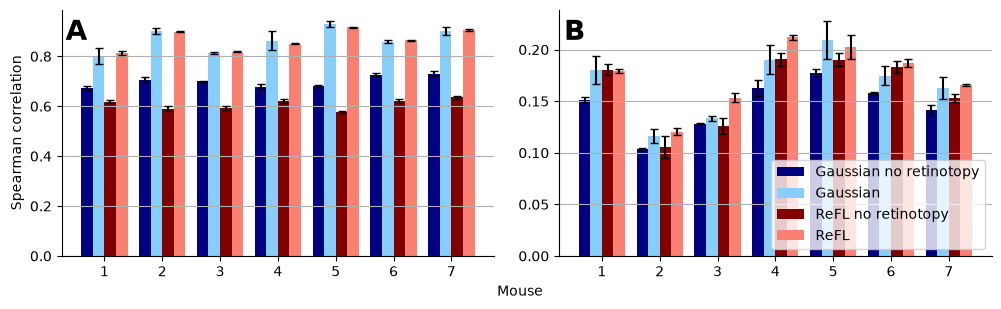

In [16]:
means = {mt: [results[mt][key][0] for key in data_keys] for mt in types}
stds  = {mt: [results[mt][key][1] for key in data_keys] for mt in types}

rf_means = {mt: [rf_results[mt][key][0] for key in data_keys] for mt in model_types}
rf_stds  = {mt: [rf_results[mt][key][1] for key in data_keys] for mt in model_types}

x = np.arange(len(data_keys))
n_types = len(types)
width = 0.8 / n_types

fig, axs = plt.subplots(1, 2, figsize=(12, 3.2))
plt.subplots_adjust(wspace=0.15)

colors = {
    'Gaussian no retinotopy': 'navy',
    'Gaussian': 'lightskyblue',
    'ReFL no retinotopy': 'maroon',
    'ReFL': 'salmon',
}

ax = axs[0]
for idx, model_type in enumerate(types):
    offset = (idx - (n_types - 1) / 2) * width
    ax.bar(
        x + offset,
        rf_means[model_type],
        width,
        yerr=rf_stds[model_type],
        capsize=3,
        label=model_type,
        color=colors[model_type],
    )

ax.set_ylabel('Spearman correlation')
ax.set_xlabel('Mouse', x=1.06)
# ax.set_ylim(0, 1)
ax.text(
    0.06, 0.85, 'A',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

ax = axs[1]
for idx, model_type in enumerate(types):
    offset = (idx - (n_types - 1) / 2) * width
    ax.bar(
        x + offset,
        means[model_type],
        width,
        yerr=stds[model_type],
        capsize=3,
        label=model_type,
        color=colors[model_type],
    )
# ax.set_ylim(0, 0.27)
ax.legend(frameon=True, loc='lower right')#, ncols=2)#, bbox_to_anchor=(1.05, 1.0))
ax.text(
    0.06, 0.85, 'B',
    transform=ax.transAxes,
    fontsize=20,
    fontweight='bold',
    va='bottom',
    ha='right',
)

for ax in axs:
    ax.set_xticks(x)
    ax.set_xticklabels(range(1, len(data_keys) + 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.spines['left'].set_visible(False)
    ax.grid(axis='y')

plt.savefig(
    'plots/results_spearman.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

In [17]:
for model_type, models in model_types.items():
    scores = []
    for model in models:
        score = get_correlations(model, dataloaders['test'], device=device, as_dict=True)
        filtered = np.concat([v for i, v in enumerate(score.values()) if i not in [4, 6]])
        assert all(filtered != 0) 
        scores.append(filtered.mean())
    scores = np.array(scores)
    print(model_type, scores.mean(), scores.std(ddof=1))

Gaussian no retinotopy 0.3872482 0.0034409978
Gaussian 0.39181054 0.0018631972
ReFL no retinotopy 0.38148293 0.0011819787
ReFL 0.39330733 0.0007717799


# training visualization

In [37]:
main_path = '../training/runs/visualizations/visualize_training_seed0' 
epochs = [1, 2, 3, 4, 6, 8, 11, 21, 51, 101]
weight_paths = [f'{main_path}/cps/model_weights{i}.pth' for i in epochs]

models = [
    load_model_from_config(main_path, dataloaders, device, weights_dir=path) 
    for path in weight_paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [40]:
masks = [
    torch.cat([model.readout[key].spatial.detach().cpu() for key in data_keys])
    for model in models
]

scores = [
    get_correlations(model, dataloaders['validation'], device=device, per_neuron=True)
    for model in models
]

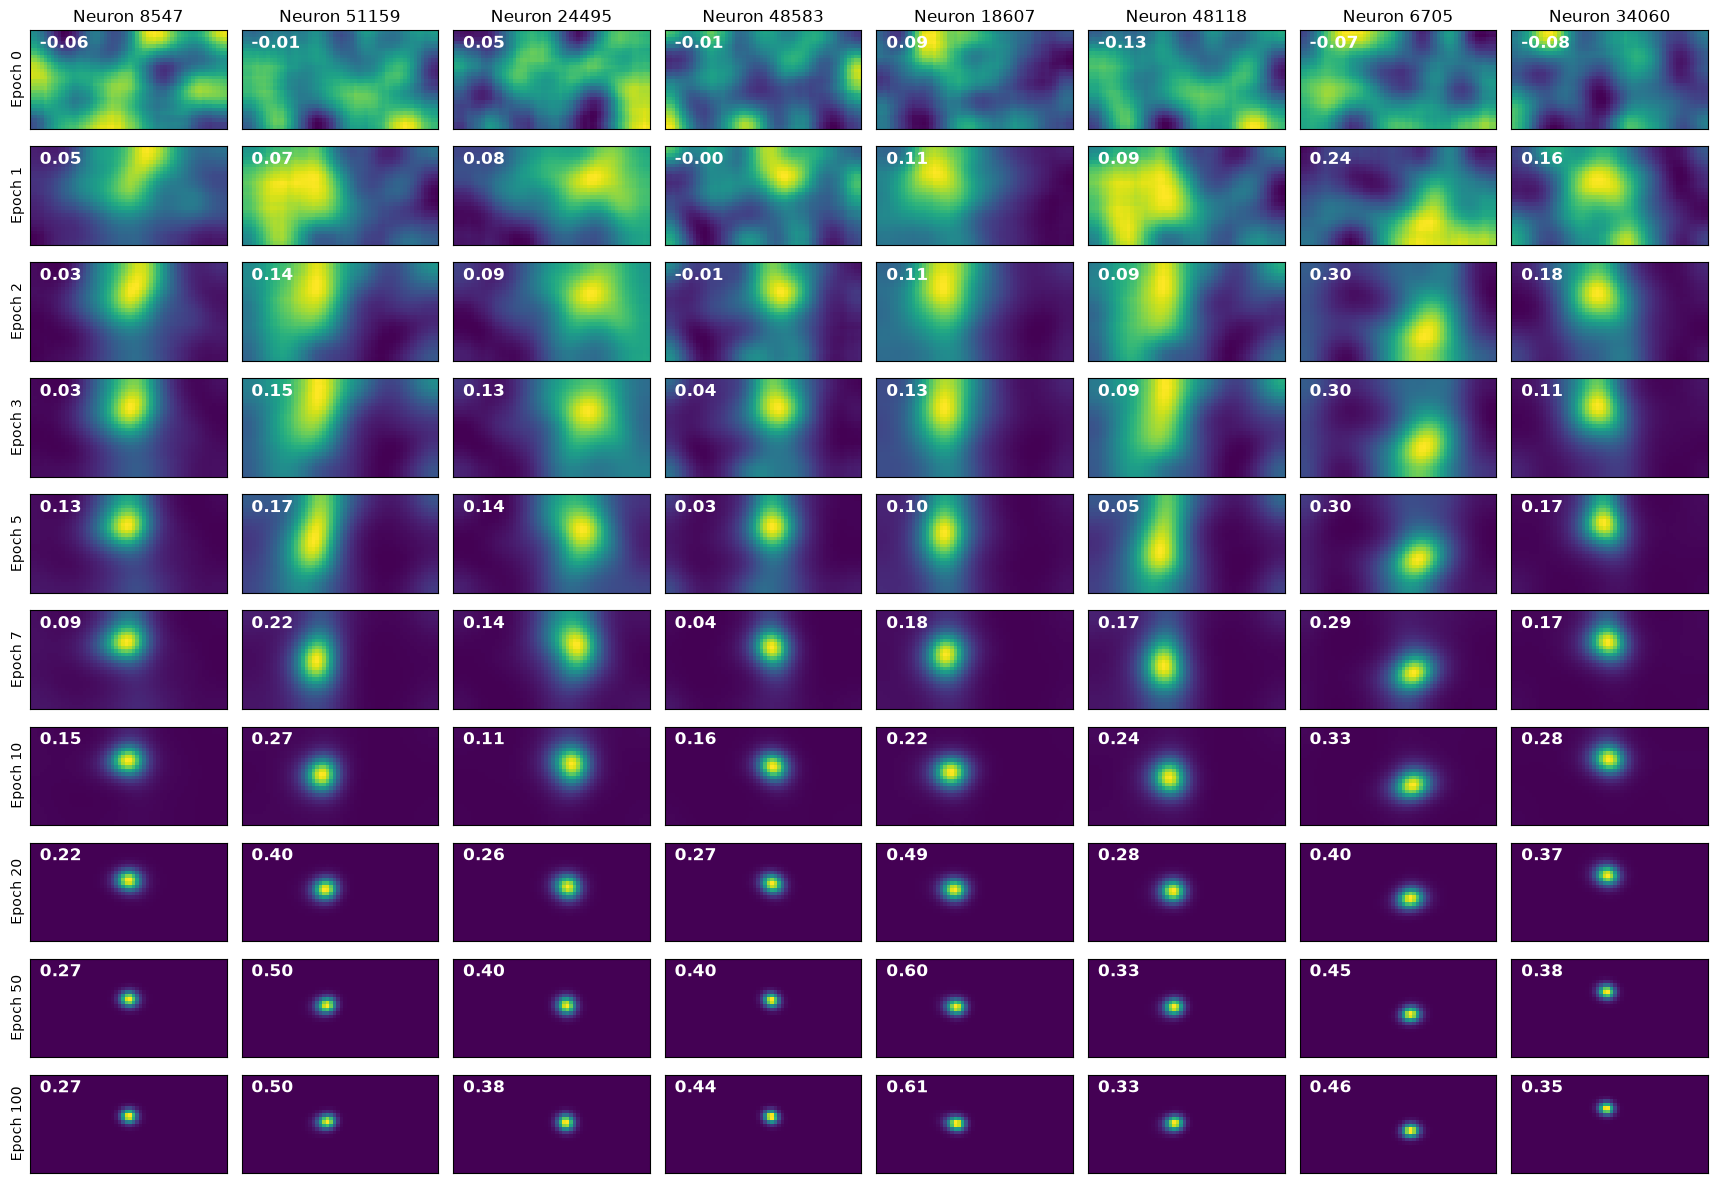

In [42]:
num_models = len(models)
n_neurons = 8
idcs = torch.randperm(masks[0].shape[0])[:n_neurons]

scale = 1.2
fig, axs = plt.subplots(num_models, n_neurons, figsize=(1.8 * scale * n_neurons, scale * num_models))

for i, (mask, score) in enumerate(zip(masks, scores)):
    for j, idx in enumerate(idcs):
        ax = axs[i, j]
        ax.imshow(mask[idx])
        ax.text(
            0.05, 0.95, f'{score[idx]:.2f}',
            transform=ax.transAxes,
            color='white',
            fontsize=12,
            ha='left', va='top',
            fontweight='bold',
        )
        ax.set_xticks([])
        ax.set_yticks([])
        
        if i == 0:
            ax.set_title(f'Neuron {idx}')

        if j == 0:
            ax.set_ylabel(f'Epoch {epochs[i] - 1}')

plt.tight_layout()

plt.savefig(
    'plots/apx_learning.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

# ari seeds

In [26]:
paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]
models = [
    load_model_from_config(path, dataloaders, device) for path in paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [27]:
num_batches = 50

In [28]:
readouts = [
    torch.cat([model.readout[k].features.squeeze().detach().cpu() for k in data_keys])
    for model in models
]

cache_file = 'data/new_readouts.pkl'
if os.path.exists(cache_file):
    with open(cache_file, 'rb') as f:
        white_readouts = pickle.load(f)
else:
    white_readouts = [
        whiten(model, dataloaders['train'], device, num_batches, t_readouts=False, n_subsample=100)
        for model in models
    ]
    
    with open(cache_file, 'wb') as f:
        pickle.dump(white_readouts, f)

In [29]:
normed_readouts = [r / r.norm(dim=1, keepdim=True) for r in readouts]
normed_white_readouts = [r / r.norm(dim=1, keepdim=True) for r in white_readouts]

In [30]:
k_range = np.unique(np.geomspace(10, 1000, num=20, dtype=int))
n_range = np.unique(np.geomspace(5, 100, num=20, dtype=int))

In [32]:
seeds = [0, 42, 123, 333, 555]
seed_curve, _ = get_ari_curve(normed_white_readouts, n_range, seeds=seeds, pairing='seeds')
feature_curve, _ = get_ari_curve(normed_white_readouts, n_range, seeds=seeds, pairing='features')

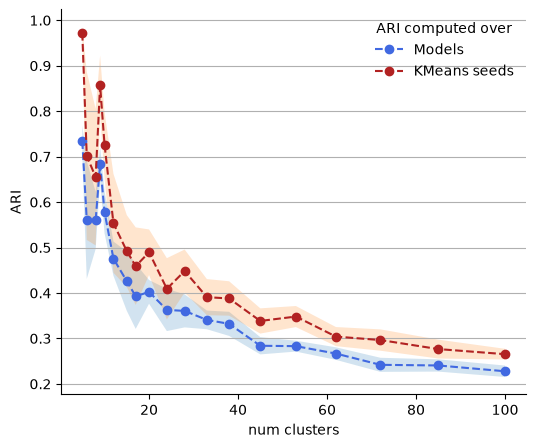

In [33]:
plt.figure(figsize=(6, 5))
m, s = np.array(feature_curve)
plt.plot(n_range, m, marker='o', linestyle='--', label='Models', color='royalblue')
plt.fill_between(n_range, m - s, m + s, alpha=0.2)

m, s = np.array(seed_curve)
plt.plot(n_range, m, marker='o', linestyle='--', label='KMeans seeds', color='firebrick')
plt.fill_between(n_range, m - s, m + s, alpha=0.2)

plt.legend(frameon=False, title='ARI computed over')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='y')
plt.xlabel('num clusters')
plt.ylabel('ARI')

plt.savefig(
    'plots/apx_ari_seeds.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)

plt.show()

# core swap

In [38]:
paths = [
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed9',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed87',
    '../training/runs/baseline/lin_grid_lin_shift/baseline_lin_lin_seed333',
]

base_models = [
    load_model_from_config(path, dataloaders, device)
    for path in paths
]

paths = [
    '../training/runs/final/final_seed9',
    '../training/runs/final/final_seed87',
    '../training/runs/final/final_seed333',
]

new_models = [
    load_model_from_config(path, dataloaders, device)
    for path in paths
]

Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
/srv/user/nathanpaul.soeding/neuralpredictors/neuralpredictors/layers/readouts/base.py:95: UserWarning: Readout is NOT initialized with mean activity but with 0!
  warnings.warn("Readout is NOT initialized with mean activity but with 0!")
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.
Passed `batch_norm_scale` as an iterable, ignoring `final_batchnorm_scale`.


In [32]:
for key in data_keys:
    new_models[1].readout[key].spatial_w = new_models[0].readout[key].spatial_w
    new_models[1].readout[key].spatial_b = new_models[0].readout[key].spatial_b
    new_models[2].readout[key].spatial_w = new_models[0].readout[key].spatial_w
    new_models[2].readout[key].spatial_b = new_models[0].readout[key].spatial_b

In [36]:
from torch.nn.functional import elu

def get_features(models, dataloaders, n_batches=1, flatten=True, n_subsample=None):
    all_features = [[] for _ in models]
    for key, loader in dataloaders.items():
        batch_features = [[] for _ in models]
        for i, batch in enumerate(loader):
            if i == n_batches:
                break
            img, target, behav = batch[:3]
            img = img.to(device)
            pupil = batch[3].to(device) if len(batch) == 4 else None
            if n_subsample is not None:
                shape = models[0].readout[key].features.squeeze().detach().cpu().shape
                n_neurons = max(shape)
                subsample = torch.randperm(n_neurons)[:n_subsample]

            for m_idx, model in enumerate(models):
                model.eval()
                with torch.no_grad():
                    _, feature = model(img, data_key=key, pupil_center=pupil, return_vec=True)
                if n_subsample is not None:
                    feature = feature[:, subsample, :]
                    # feature = feature[:, neurons[key], :]
                batch_features[m_idx].append(feature.detach().cpu())

        for m_idx in range(len(models)):
            all_features[m_idx].append(torch.cat(batch_features[m_idx]))

    if flatten:
        return [torch.cat([f.flatten(0, 1) for f in feats]) for feats in all_features]
    return all_features

def fit_linear_transform(X, Y, lam=1e-3):
    n, d = X.shape

    ones = torch.ones(n, 1)
    X_aug = torch.cat([X, ones], dim=1)          # (n, d+1)

    XtX = X_aug.T @ X_aug                         # (d+1, d+1)
    XtY = X_aug.T @ Y                             # (d+1, d_out)

    # Ridge penalty: lambda * I, but don't regularize the bias term
    reg = lam * torch.eye(d + 1)
    reg[d, d] = 0.0  # leave bias unpenalized

    W_aug = torch.linalg.solve(XtX + reg, XtY)

    W = W_aug[:d, :]
    b = W_aug[d, :]
    return W, b

def prediction(features, readouts, biases, fW=None, fb=None):
    preds = []
    for X, r, b in zip(features, readouts, biases):
        if fW is not None:
            y = torch.einsum("bnc,nc->bn", X @ fW + fb, r) + b
        else:
            y = torch.einsum("bnc,nc->bn", X, r) + b
        preds.append(elu(y) + 1)
    return preds

def correlate(x_list, y_list):
    x = torch.cat(x_list, dim=1)
    y = torch.cat(y_list, dim=1)

    xc = x - x.mean(0)
    yc = y - y.mean(0)

    return (xc * yc).sum(0) / ((xc * xc).sum(0) * (yc * yc).sum(0)).sqrt()

def core_swap(models, dataloaders, train_batches=1, val_batches=1, t_readouts=False, n_subsample=100, lam=0.0):
    if n_subsample is not None:
        neurons = {}
        for key in data_keys:
            features = models[0].readout[key].features.squeeze().detach().cpu()
            n_neurons = features.shape[1] if t_readouts else features.shape[0]
            neurons[key] = torch.randperm(n_neurons)[:n_subsample]
    else:
        neurons = None
    if t_readouts:
        readouts = [
            [model.readout[k].features.squeeze().detach().cpu().T for k in data_keys]
            for model in models
        ]
    else:
        readouts = [
            [model.readout[k].features.squeeze().detach().cpu() for k in data_keys]
            for model in models
        ]
    biases = [
        [model.readout[k].bias.squeeze().detach().cpu() for k in data_keys]
        for model in models
    ]
    train_features = get_features(models, dataloaders['train'], train_batches, flatten=True, n_subsample=n_subsample)
    val_features = get_features(models, dataloaders['validation'], val_batches, flatten=False)

    num_models = len(models)
    corrs = []
    for x in range(num_models):
        for y in range(num_models):
            if x == y:
                continue

            W, b = fit_linear_transform(train_features[x], train_features[y], lam)
            pred = prediction(val_features[x], readouts[y], biases[y], fW=W, fb=b)
            target = prediction(val_features[y], readouts[y], biases[y])
            corr = correlate(pred, target)
            corrs.append(corr)

    return torch.stack(corrs).mean(0)

In [ ]:
result = core_swap(base_models, dataloaders, t_readouts=True, train_batches=50, val_batches=3, n_subsample=100, lam=0.0)

tensor(0.8982)

In [ ]:
new_result = core_swap(new_models, dataloaders, t_readouts=False, train_batches=50, val_batches=3, n_subsample=100, lam=0.0)

tensor(0.9231)

In [50]:
result.mean(), new_result.mean()

(tensor(0.8997), tensor(0.9238))

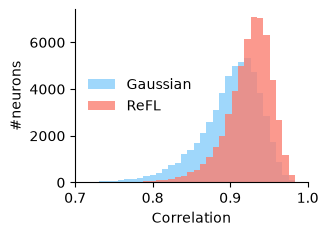

In [67]:
fig, ax = plt.subplots(figsize=(3, 2.25))

bins = torch.linspace(0.6, 1, steps=50)
ax.hist(result, bins=bins, label='Gaussian', alpha=0.8, color='lightskyblue')
ax.hist(new_result, bins=bins, label='ReFL', alpha=0.8, color='salmon')
# ax.set_yscale('log')
ax.set_ylabel('#neurons')
ax.set_xlabel('Correlation')
# ax.grid(axis='x')
ax.set_xlim(0.7, 1.0)
ax.legend(frameon=False, loc='center left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(
    'plots/results_core_swap.pdf',
    transparent=True,
    bbox_inches='tight',
    pad_inches=0,
)
plt.show()

# new